In [1]:
import numpy as np
import networkx as nx
import pandas as pd
from tqdm.auto import tqdm
import itertools
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from causallearn.utils.cit import CIT
from sklearn.ensemble import RandomForestRegressor

try:
    from networkx.algorithms.d_separation import is_d_separator
except ImportError:
    from networkx.algorithms.d_separation import d_separated as is_d_separator

/home/s4517962/micromamba/envs/thesis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Helpers

In [2]:
def markov_blanket_oracle_from_graph(G, observed_nodes, target):

    observed_nodes = list(observed_nodes)

    MB = []

    for v in observed_nodes:
        if v == target:
            continue

        conditioning_set = set(
            node for node in observed_nodes
            if node not in [target, v]
        )

        separated = is_d_separator(
            G,
            {target},
            {v},
            conditioning_set
        )

        if not separated:
            MB.append(v)

    return sorted(MB)

In [ ]:
def estimate_true_effect_by_intervention(
    graph_info,
    x="X",
    y="Y",
    x0=-1.0,
    x1=1.0,
    beta=1.0,
    n_mc=100_000,
    rng=None,
    noise_scale=1.0,
):

    if beta == 0:
        order = graph_info["order"]
        B = graph_info["B"].loc[order, order].to_numpy(dtype=float)
        total_effect_matrix = np.linalg.inv(np.eye(len(order)) - B)

        x_idx = order.index(x)
        y_idx = order.index(y)
        effect_per_unit = total_effect_matrix[x_idx, y_idx]

        return float(effect_per_unit * (x1 - x0))

    if rng is None:
        rng = np.random.default_rng()

    # Use two child generators so the function is reproducible but independent.
    seed_0, seed_1 = rng.integers(0, 2**32 - 1, size=2)

    _, D0_full = simulate_nonlinear_scm(
        graph_info=graph_info,
        n=n_mc,
        beta=beta,
        rng=np.random.default_rng(seed_0),
        noise_scale=noise_scale,
        intervention={x: x0},
        return_full=True,
    )

    _, D1_full = simulate_nonlinear_scm(
        graph_info=graph_info,
        n=n_mc,
        beta=beta,
        rng=np.random.default_rng(seed_1),
        noise_scale=noise_scale,
        intervention={x: x1},
        return_full=True,
    )

    true_effect = D1_full[y].mean() - D0_full[y].mean()

    return true_effect


In [ ]:
def estimate_effect_gformula(
    D_obs,
    x="X",
    y="Y",
    Z=None,
    x0=None,
    x1=None,
    model=None,
    random_state=0,
    estimator="auto",
    beta=None,
):

    if Z is None:
        Z = []

    if x0 is None:
        x0 = D_obs[x].quantile(0.25)

    if x1 is None:
        x1 = D_obs[x].quantile(0.75)

    Z = list(Z)
    features = [x] + Z

    if estimator == "auto":
        estimator = "linear" if beta == 0 else "rf"

    if estimator == "linear":
        X_design = sm.add_constant(D_obs[features], has_constant="add")
        fitted = sm.OLS(D_obs[y], X_design).fit()
        return float(fitted.params[x] * (x1 - x0))

    if estimator != "rf":
        raise ValueError("estimator must be 'auto', 'linear', or 'rf'")

    if model is None:
        model = RandomForestRegressor(
            n_estimators=300,
            min_samples_leaf=10,
            random_state=random_state,
            n_jobs=-1,
        )

    model.fit(D_obs[features], D_obs[y])

    D_x0 = D_obs[features].copy()
    D_x1 = D_obs[features].copy()

    D_x0[x] = x0
    D_x1[x] = x1

    pred_x0 = model.predict(D_x0)
    pred_x1 = model.predict(D_x1)

    return float(np.mean(pred_x1 - pred_x0))


In [ ]:
def ci_test(X, Y, Z, D_obs, alpha=0.05, method="kci"):

    Z = list(Z)

    columns = D_obs.columns.tolist()
    col_to_idx = {col: i for i, col in enumerate(columns)}

    X_idx = col_to_idx[X]
    Y_idx = col_to_idx[Y]
    Z_idx = [col_to_idx[z] for z in Z]

    data_np = D_obs.to_numpy(dtype=float)

    cache_key = (id(D_obs), method)

    if not hasattr(ci_test, "_cit_cache"):
        ci_test._cit_cache = {}

    if cache_key not in ci_test._cit_cache:
        ci_test._cit_cache[cache_key] = CIT(data_np, method)

    cit_obj = ci_test._cit_cache[cache_key]

    p_value = cit_obj(X_idx, Y_idx, Z_idx)

    indep = p_value > alpha

    return indep, p_value

In [6]:
def r1(w, Z, D_obs, x = 'X', y = 'Y', alpha_dep = 0.01, alpha_indep = 0.1):
    Z = list(Z)
    Z_plus_x = Z + [x]

    indep1, pval1 = ci_test(w, y, Z, D_obs, alpha_dep)
    indep2, pval2 = ci_test(w, y, Z_plus_x, D_obs, alpha_indep)

    cond_1 = not indep1
    cond_2 = indep2

    return {
        "R1": cond_1 and cond_2,
        "w": w,
        "Z": list(Z),
        "cond1_dep_given_Z": cond_1,
        "cond2_indep_given_Z_plus_x": cond_2,
        "pval1": pval1,
        "pval2": pval2
    }

In [7]:
def r2(w, Z, D_obs, x='X', y='Y', alpha_dep=0.01, alpha_indep=0.1):
    Z = list(Z)

    indep1, pval1 = ci_test(w, x, Z, D_obs, alpha_dep)
    indep2, pval2 = ci_test(w, y, Z, D_obs, alpha_indep)

    cond_1 = not indep1
    cond_2 = indep2

    return {
        "R2": cond_1 and cond_2,
        "w": w,
        "Z": list(Z),
        "cond1_dep_w_x_given_Z": cond_1,
        "cond2_indep_w_y_given_Z": cond_2,
        "pval1": pval1,
        "pval2": pval2
    }

In [8]:
def r2a(Z, D_obs, x='X', y='Y', alpha_indep=0.1):
    Z = list(Z)

    indep_xy, pval = ci_test(x, y, Z, D_obs, alpha_indep)

    return {
        "R2a": indep_xy,
        "Z": list(Z),
        "cond_indep_x_y_given_Z": indep_xy,
        "pval": pval
    }

In [ ]:
def simulate_nonlinear_scm(
    graph_info,
    n,
    beta=1.0,
    rng=None,
    noise_scale=1.0,
    intervention=None,
    return_full=False,
):

    if rng is None:
        rng = np.random.default_rng()

    if intervention is None:
        intervention = {}

    order = graph_info["order"]
    observed_nodes = graph_info["observed_nodes"]
    B = graph_info["B"]

    noise = pd.DataFrame(
        rng.normal(0, noise_scale, size=(n, len(order))),
        columns=order,
    )

    D_full = pd.DataFrame(0.0, index=np.arange(n), columns=order)

    for node in order:
        if node in intervention:
            D_full[node] = intervention[node]
            continue

        parents = B.index[B[node] != 0].tolist()

        if len(parents) == 0:
            D_full[node] = noise[node].values
        else:
            parent_values = D_full[parents].to_numpy(dtype=float)
            coeffs = B.loc[parents, node].to_numpy(dtype=float)

            eta = parent_values @ coeffs
            nonlinear_part = np.tanh(eta)

            D_full[node] = (
                (1.0 - beta) * eta
                + beta * nonlinear_part
                + noise[node].values
            )

    D_obs = D_full[observed_nodes].copy()

    if return_full:
        return D_obs, D_full

    return D_obs

## Generate synthetic data

In [ ]:
def generate_random_dataset(
    n,
    rng=None,
    n_obs=10,
    n_latent=0,
    p=0.10,
    beta=1,
    treatment="X",
    outcome="Y",
    force_effect=True,
    noise_scale=1.0,
    n_mc_true_effect=100_000,
    coefficient_low=0.5,
    coefficient_high=1.5,
    signed_coefficients=False,
    return_full=False,
):
    
    if rng is None:
        rng = np.random.default_rng()

    # ============================================================
    # 1. Generate random DAG
    # ============================================================

    latent_nodes = [f"U{i}" for i in range(n_latent)]
    observed_covariates = [f"V{i}" for i in range(n_obs)]

    background_nodes = latent_nodes + observed_covariates
    background_order = list(background_nodes)
    rng.shuffle(background_order)

    # Pretreatment order:
    # all latent and observed covariates are before X and Y.
    # Therefore X/Y cannot cause observed covariates.
    order = background_order + [treatment, outcome]
    nodes = order.copy()
    observed_nodes = observed_covariates + [treatment, outcome]

    B = pd.DataFrame(0.0, index=nodes, columns=nodes)
    edges = []

    def sample_coeff():
        coeff = rng.uniform(coefficient_low, coefficient_high)
        if signed_coefficients and rng.random() < 0.5:
            coeff *= -1
        return coeff

    for i, parent in enumerate(order):
        for child in order[i + 1:]:

            if parent == treatment and child == outcome:
                if force_effect is True:
                    add_edge = True
                elif force_effect is False:
                    add_edge = False
                else:
                    add_edge = rng.random() < p
            else:
                add_edge = rng.random() < p

            if add_edge:
                edges.append((parent, child))
                B.loc[parent, child] = sample_coeff()

    edges = list(dict.fromkeys(edges))

    G = nx.DiGraph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)

    isolated_nodes = [node for node in nodes if G.degree(node) == 0]
    isolated_observed_nodes = [node for node in observed_nodes if G.degree(node) == 0]

    has_direct_effect = G.has_edge(treatment, outcome)
    has_total_effect_path = nx.has_path(G, treatment, outcome)

    # ============================================================
    # 2. Compute oracle Markov blankets for diagnostics
    # ============================================================


    actual_MB_x = markov_blanket_oracle_from_graph(
        G=G,
        observed_nodes=observed_nodes,
        target=treatment
    )

    actual_MB_y = markov_blanket_oracle_from_graph(
        G=G,
        observed_nodes=observed_nodes,
        target=outcome
    )

    graph_info = {
        "nodes": nodes,
        "observed_nodes": observed_nodes,
        "latent_nodes": latent_nodes,
        "order": order,
        "edges": edges,
        "B": B,
        "G": G,
        "p": p,
        "n_obs": n_obs,
        "n_latent": n_latent,
        "isolated_nodes": isolated_nodes,
        "isolated_observed_nodes": isolated_observed_nodes,
        "n_isolated_nodes": len(isolated_nodes),
        "n_isolated_observed_nodes": len(isolated_observed_nodes),
        "has_direct_effect": has_direct_effect,
        "has_total_effect_path": has_total_effect_path,
        "actual_MB_x": actual_MB_x,
        "actual_MB_y": actual_MB_y,
    }

    # ============================================================
    # 3. Simulate nonlinear SCM
    # ============================================================

    noise = pd.DataFrame(
        rng.normal(0, noise_scale, size=(n, len(order))),
        columns=order,
    )

    D_full = pd.DataFrame(0.0, index=np.arange(n), columns=order)

    for node in order:

        parents = B.index[B[node] != 0].tolist()

        if len(parents) == 0:
            D_full[node] = noise[node].values

        else:
            parent_values = D_full[parents].to_numpy(dtype=float)
            coeffs = B.loc[parents, node].to_numpy(dtype=float)

            eta = parent_values @ coeffs
            nonlinear_part = np.tanh(eta)

            D_full[node] = (
                (1.0 - beta) * eta
                + beta * nonlinear_part
                + noise[node].values
            )

    D_obs = D_full[observed_nodes].copy()

    # ============================================================
    # 4. Estimate true causal effect by intervention
    # ============================================================

    x0 = -1.0
    x1 = 1.0

    true_ce = estimate_true_effect_by_intervention(
        graph_info=graph_info,
        x=treatment,
        y=outcome,
        x0=x0,
        x1=x1,
        beta=beta,
        n_mc=n_mc_true_effect,
        rng=rng,
        noise_scale=noise_scale,
    )

    graph_info["x0"] = x0
    graph_info["x1"] = x1
    graph_info["beta"] = beta
    graph_info["noise_scale"] = noise_scale
    graph_info["coefficient_low"] = coefficient_low
    graph_info["coefficient_high"] = coefficient_high
    graph_info["signed_coefficients"] = signed_coefficients

    if return_full:
        return D_obs, D_full, B, true_ce, graph_info

    return D_obs, B, true_ce, graph_info


## Main Algorithms

### EHS

In [11]:
def alg_EHS(D_obs, x='X', y='Y', alpha_dep=0.01, alpha_indep=0.15, max_z_size=None, x0=None, x1=None, beta=None, estimator='auto'):
    W = [col for col in D_obs.columns if col not in [x, y]]
    if max_z_size is None:
        max_z_size = len(W)
    
    VASs = []
    R1_count = 0
    R2_count = 0
    R2a_count = 0
    CI_num = 0

    # R2 i)
    for k in range(max_z_size + 1):
        for Z in itertools.combinations(W, k):
            Z = list(Z)

            out_r2a = r2a(Z, D_obs, x=x, y=y, alpha_indep=alpha_indep)
            CI_num += 1

            if out_r2a["R2a"]:
                R2_count += 1
                R2a_count += 1

    # R1 i)
    for k in range(max_z_size + 1):
        for Z in itertools.combinations(W, k):
            Z = list(Z)
            for w in W:
                if w in Z:
                    continue
                out_r1 = r1(w, Z, D_obs, x, y, alpha_dep, alpha_indep)
                CI_num += 2

                if out_r1["R1"]:
                    R1_count += 1
                    if Z not in VASs:
                        VASs.append(Z)

                out_r2 = r2(w, Z, D_obs, x, y, alpha_dep, alpha_indep)
                CI_num += 2

                if out_r2["R2"]:
                    R2_count += 1


    if R1_count > 0 and R2_count > 0:
        decision = '?'
        ate = None
    elif R1_count > 0:
        ates = [estimate_effect_gformula(D_obs, x=x, y=y, Z=Z, x0=x0, x1=x1, beta=beta, estimator=estimator) for Z in VASs]
        ate = float(np.mean(ates)) if len(ates) > 0 else None
        decision = '+'
    elif R2_count > 0:
        decision = '0'
        ate = 0.0
    else:
        decision = '?'
        ate = None
    return {
        "decision": decision,
        "VASs": VASs,
        "ATE": ate,
        "CI_num": CI_num,
        "R1_count": R1_count,
        "R2_count": R2_count
    }

### LPC-ID


In [ ]:
def alg_lpc_id(
    D_obs,
    x="X",
    y="Y",
    max_z_size=None,
    max_pc_cond_size=None,
    alpha_pc=0.40,
    alpha_dep=0.01,
    alpha_indep=0.20,
    ci_method="kci",
    x0=None,
    x1=None,
    beta=None,
    estimator="auto",
    use_pc_stable=True,
):
    """
    Local PC + Entner/LSAS completion.

    Assumptions:
      - no latent variables
      - all covariates are pre-treatment
      - Y is not a causal ancestor of X
      - X and Y are not causal ancestors of covariates

    This version does NOT initialize the full graph.
    It only initializes local candidate edges:
      X--W, Y--W, and X--Y.

    It also does NOT collect Entner evidence during PC.
    Entner/LSAS rules are checked only after local MB recovery.
    """

    observed_nodes = D_obs.columns.tolist()
    W = [node for node in observed_nodes if node not in [x, y]]

    if not (alpha_dep < alpha_indep):
        raise ValueError("Expected alpha_dep < alpha_indep.")

    if alpha_pc < alpha_indep:
        print(
            "Warning: alpha_pc < alpha_indep. "
            "PC may delete edges using weaker independence evidence than the rule system accepts."
        )

    # ------------------------------------------------------------------
    # Local working skeleton: only X--W, Y--W, and X--Y
    # ------------------------------------------------------------------
    skeleton = nx.Graph()
    skeleton.add_nodes_from(observed_nodes)

    for w in W:
        skeleton.add_edge(x, w)
        skeleton.add_edge(y, w)

    skeleton.add_edge(x, y)

    ci_cache = {}
    sepsets = {}

    r1_hits = []
    r2_hits = []

    n_ci_requests = 0
    n_ci_executed = 0
    r1_count = 0
    r2_count = 0

    if max_pc_cond_size is None:
        pc_max_cond_size = len(W)
    else:
        pc_max_cond_size = max_pc_cond_size

    # ------------------------------------------------------------------
    # Local PC phase
    # ------------------------------------------------------------------
    for l in range(pc_max_cond_size + 1):

        deg_x_local = len([n for n in skeleton.neighbors(x) if n != y])
        deg_y_local = len([n for n in skeleton.neighbors(y) if n != x])

        if l > max(deg_x_local, deg_y_local):
            break

        any_test_possible_this_round = False
        edges_to_remove = []

        if use_pc_stable:
            adj_snapshot = {
                node: set(skeleton.neighbors(node))
                for node in skeleton.nodes
            }
        else:
            adj_snapshot = None

        pairs_to_check = [
            (A, B)
            for A, B in list(skeleton.edges())
            if x in (A, B) or y in (A, B)
        ]

        for A, B in pairs_to_check:
            if not skeleton.has_edge(A, B):
                continue

            if use_pc_stable:
                adjA = list(adj_snapshot[A] - {B})
                adjB = list(adj_snapshot[B] - {A})
            else:
                adjA = [n for n in skeleton.neighbors(A) if n != B]
                adjB = [n for n in skeleton.neighbors(B) if n != A]

            if len(adjA) < l and len(adjB) < l:
                continue

            any_test_possible_this_round = True

            candidate_sets = set()

            if len(adjA) >= l:
                for Z in itertools.combinations(adjA, l):
                    candidate_sets.add(tuple(sorted(Z)))

            if len(adjB) >= l:
                for Z in itertools.combinations(adjB, l):
                    candidate_sets.add(tuple(sorted(Z)))

            for Z in candidate_sets:
                Z = tuple(sorted(Z))

                key = (A, B, Z)
                rev_key = (B, A, Z)

                n_ci_requests += 1

                if key in ci_cache:
                    p_value = ci_cache[key]
                elif rev_key in ci_cache:
                    p_value = ci_cache[rev_key]
                    ci_cache[key] = p_value
                else:
                    n_ci_executed += 1
                    _, p_value = ci_test(
                        A,
                        B,
                        list(Z),
                        D_obs,
                        alpha=alpha_pc,
                        method=ci_method,
                    )
                    ci_cache[key] = p_value
                    ci_cache[rev_key] = p_value

                if p_value > alpha_pc:
                    edges_to_remove.append((A, B, Z))
                    break

        for A, B, Z in edges_to_remove:
            if skeleton.has_edge(A, B):
                skeleton.remove_edge(A, B)
                sepsets[frozenset([A, B])] = list(Z)

        if not any_test_possible_this_round:
            break

    # ------------------------------------------------------------------
    # Construct local Markov blanket candidates
    # ------------------------------------------------------------------
    xy_adjacent = skeleton.has_edge(x, y)
    Ne_x = set(skeleton.neighbors(x))
    Ne_y = set(skeleton.neighbors(y))

    # Under pre-treatment, Y has no children, so MB(Y) = Adj(Y).
    MB_y = sorted(Ne_y - {x})

    # If X--Y remains, X may have child Y, so Y's other parents are spouses of X.
    # Under pre-treatment, these are captured by Ne(Y).
    if xy_adjacent:
        MB_x = sorted((Ne_x | Ne_y) - {x, y})
    else:
        MB_x = sorted(Ne_x - {y})

    # ------------------------------------------------------------------
    # LSAS / Entner completion over recovered MB_y and MB_x
    # ------------------------------------------------------------------
    if max_z_size is None:
        rule_max_z_size = len(MB_y)
    else:
        rule_max_z_size = min(max_z_size, len(MB_y))

    # R2a: X independent Y | Z
    for z_size in range(rule_max_z_size + 1):
        for Z in itertools.combinations(MB_y, z_size):

            Z = tuple(sorted(Z))

            key_xy = (x, y, Z)
            rev_key_xy = (y, x, Z)

            n_ci_requests += 1

            if key_xy in ci_cache:
                p_xy = ci_cache[key_xy]
            elif rev_key_xy in ci_cache:
                p_xy = ci_cache[rev_key_xy]
                ci_cache[key_xy] = p_xy
            else:
                n_ci_executed += 1
                _, p_xy = ci_test(
                    x,
                    y,
                    list(Z),
                    D_obs,
                    alpha=alpha_pc,
                    method=ci_method,
                )
                ci_cache[key_xy] = p_xy
                ci_cache[rev_key_xy] = p_xy

            if p_xy > alpha_indep:
                r2_count += 1
                r2_hits.append({
                    "reason": "R2a_LSAS_completion",
                    "Z": list(Z),
                })

    # R1 and R2b
    for w in MB_x:
        MB_y_without_w = [node for node in MB_y if node != w]

        if max_z_size is None:
            rule_max_z_size_w = len(MB_y_without_w)
        else:
            rule_max_z_size_w = min(max_z_size, len(MB_y_without_w))

        for z_size in range(rule_max_z_size_w + 1):
            for Z in itertools.combinations(MB_y_without_w, z_size):

                Z = tuple(sorted(Z))

                if w in Z or x in Z or y in Z:
                    continue

                # ------------------------------------------------------
                # Test w _||_ Y | Z
                # ------------------------------------------------------
                key_wy = (w, y, Z)
                rev_key_wy = (y, w, Z)

                n_ci_requests += 1

                if key_wy in ci_cache:
                    p_wy = ci_cache[key_wy]
                elif rev_key_wy in ci_cache:
                    p_wy = ci_cache[rev_key_wy]
                    ci_cache[key_wy] = p_wy
                else:
                    n_ci_executed += 1
                    _, p_wy = ci_test(
                        w,
                        y,
                        list(Z),
                        D_obs,
                        alpha=alpha_pc,
                        method=ci_method,
                    )
                    ci_cache[key_wy] = p_wy
                    ci_cache[rev_key_wy] = p_wy

                # ------------------------------------------------------
                # R1: w dependent Y | Z and w independent Y | Z + X
                # ------------------------------------------------------
                if p_wy < alpha_dep:

                    Z_plus_x = tuple(sorted(list(Z) + [x]))
                    key_wy_x = (w, y, Z_plus_x)
                    rev_key_wy_x = (y, w, Z_plus_x)

                    n_ci_requests += 1

                    if key_wy_x in ci_cache:
                        p_wy_x = ci_cache[key_wy_x]
                    elif rev_key_wy_x in ci_cache:
                        p_wy_x = ci_cache[rev_key_wy_x]
                        ci_cache[key_wy_x] = p_wy_x
                    else:
                        n_ci_executed += 1
                        _, p_wy_x = ci_test(
                            w,
                            y,
                            list(Z_plus_x),
                            D_obs,
                            alpha=alpha_pc,
                            method=ci_method,
                        )
                        ci_cache[key_wy_x] = p_wy_x
                        ci_cache[rev_key_wy_x] = p_wy_x

                    if p_wy_x > alpha_indep:
                        r1_count += 1
                        r1_hits.append({
                            "reason": "R1_LSAS_completion",
                            "w": w,
                            "Z": list(Z),
                        })

                # ------------------------------------------------------
                # R2b: w dependent X | Z and w independent Y | Z
                # ------------------------------------------------------
                key_wx = (w, x, Z)
                rev_key_wx = (x, w, Z)

                n_ci_requests += 1

                if key_wx in ci_cache:
                    p_wx = ci_cache[key_wx]
                elif rev_key_wx in ci_cache:
                    p_wx = ci_cache[rev_key_wx]
                    ci_cache[key_wx] = p_wx
                else:
                    n_ci_executed += 1
                    _, p_wx = ci_test(
                        w,
                        x,
                        list(Z),
                        D_obs,
                        alpha=alpha_pc,
                        method=ci_method,
                    )
                    ci_cache[key_wx] = p_wx
                    ci_cache[rev_key_wx] = p_wx

                if p_wx < alpha_dep and p_wy > alpha_indep:
                    r2_count += 1
                    r2_hits.append({
                        "reason": "R2b_LSAS_completion",
                        "w": w,
                        "Z": list(Z),
                    })

    # ------------------------------------------------------------------
    # Decision rule: LSAS-style priority, R1 before R2
    # ------------------------------------------------------------------
    if len(r1_hits) > 0:
        decision = "+"
        vas_list = []

        for hit in r1_hits:
            if hit["Z"] not in vas_list:
                vas_list.append(hit["Z"])

        ates = [
            estimate_effect_gformula(
                D_obs,
                x=x,
                y=y,
                Z=Z,
                x0=x0,
                x1=x1,
                beta=beta,
                estimator=estimator,
            )
            for Z in vas_list
        ]

        ate = float(np.mean(ates)) if len(ates) > 0 else None

    elif len(r2_hits) > 0:
        decision = "0"
        vas_list = []
        ate = 0.0

    else:
        decision = "?"
        vas_list = []
        ate = None

    return {
        "decision": decision,
        "VASs": vas_list,
        "ATE": ate,
        "CI_num": n_ci_requests,
        "CI_num_executed": n_ci_executed,
        "R1_count": r1_count,
        "R2_count": r2_count,
        "r1_hits": r1_hits,
        "r2_hits": r2_hits,
        "sepsets": sepsets,
        "MB_x": MB_x,
        "MB_y": MB_y,
        "Ne_x": sorted(Ne_x),
        "Ne_y": sorted(Ne_y),
        "xy_adjacent": xy_adjacent,
        "local_edges_remaining": list(skeleton.edges()),
        "ci_cache_size": len(ci_cache),
    }

In [15]:
def alg_ea_iamb(
    D_obs,
    x='X',
    y='Y',
    max_z_size=None,
    alpha_dep=0.01,
    alpha_indep=0.20,
    ci_method='kci',
    x0=None,
    x1=None,
    beta=None,
    estimator='auto',
):
    """
    Entner-aware IAMB + LSAS completion.

    Assumptions:
      - no latent variables
      - all covariates are pre-treatment
      - Y is not a causal ancestor of X
      - X and Y are not causal ancestors of covariates

    IAMB is used to recover MB(Y) and MB(X).
    During IAMB tests, Entner-style R1/R2 evidence is collected on the fly.
    After MB recovery, the usual LSAS-style completion is run over the recovered blankets.
    """

    observed_nodes = D_obs.columns.tolist()
    W = [node for node in observed_nodes if node not in [x, y]]

    ci_cache = {}
    r1_hits = []
    r2_hits = []

    n_ci_requests = 0
    n_ci_executed = 0
    r1_count = 0
    r2_count = 0

    # ------------------------------------------------------------------
    # IAMB for target Y
    # ------------------------------------------------------------------
    target = y
    CMB_y = []

    while True:
        best_var = None
        best_p = 1.0

        candidates = [v for v in observed_nodes if v != target and v not in CMB_y]

        for v in candidates:
            Z = tuple(sorted(CMB_y))

            key = (v, target, Z)
            rev_key = (target, v, Z)

            n_ci_requests += 1

            if key in ci_cache:
                p_value = ci_cache[key]
            elif rev_key in ci_cache:
                p_value = ci_cache[rev_key]
                ci_cache[key] = p_value
            else:
                n_ci_executed += 1
                _, p_value = ci_test(
                    v,
                    target,
                    list(Z),
                    D_obs,
                    alpha=alpha_indep,
                    method=ci_method,
                )
                ci_cache[key] = p_value
                ci_cache[rev_key] = p_value

            # ----------------------------------------------------------
            # On-the-go Entner hooks for tests v ? Y | Z
            # ----------------------------------------------------------
            rule_size_ok = max_z_size is None or len(Z) <= max_z_size

            if rule_size_ok:
                # R2a: X independent Y | Z
                if v == x and p_value > alpha_indep:
                    r2_count += 1
                    r2_hits.append({
                        "reason": "R2a_IAMB_Y",
                        "Z": list(Z),
                    })

                # R1: w dependent Y | Z and w independent Y | Z + X
                if v in W and p_value < alpha_dep and x not in Z and v not in Z:
                    Z_plus_x = tuple(sorted(list(Z) + [x]))

                    key_r1 = (v, y, Z_plus_x)
                    rev_key_r1 = (y, v, Z_plus_x)

                    n_ci_requests += 1

                    if key_r1 in ci_cache:
                        p_r1 = ci_cache[key_r1]
                    elif rev_key_r1 in ci_cache:
                        p_r1 = ci_cache[rev_key_r1]
                        ci_cache[key_r1] = p_r1
                    else:
                        n_ci_executed += 1
                        _, p_r1 = ci_test(
                            v,
                            y,
                            list(Z_plus_x),
                            D_obs,
                            alpha=alpha_indep,
                            method=ci_method,
                        )
                        ci_cache[key_r1] = p_r1
                        ci_cache[rev_key_r1] = p_r1

                    if p_r1 > alpha_indep:
                        r1_count += 1
                        r1_hits.append({
                            "reason": "R1_IAMB_Y",
                            "w": v,
                            "Z": list(Z),
                        })

                # R2b: w dependent X | Z and w independent Y | Z
                if v in W and p_value > alpha_indep and x not in Z and v not in Z:
                    key_wx = (v, x, Z)
                    rev_key_wx = (x, v, Z)

                    n_ci_requests += 1

                    if key_wx in ci_cache:
                        p_wx = ci_cache[key_wx]
                    elif rev_key_wx in ci_cache:
                        p_wx = ci_cache[rev_key_wx]
                        ci_cache[key_wx] = p_wx
                    else:
                        n_ci_executed += 1
                        _, p_wx = ci_test(
                            v,
                            x,
                            list(Z),
                            D_obs,
                            alpha=alpha_indep,
                            method=ci_method,
                        )
                        ci_cache[key_wx] = p_wx
                        ci_cache[rev_key_wx] = p_wx

                    if p_wx < alpha_dep:
                        r2_count += 1
                        r2_hits.append({
                            "reason": "R2b_IAMB_Y",
                            "w": v,
                            "Z": list(Z),
                        })

            if p_value < best_p:
                best_p = p_value
                best_var = v

        if best_var is not None and best_p < alpha_dep:
            CMB_y.append(best_var)
        else:
            break

    # Backward phase for Y
    changed = True

    while changed:
        changed = False

        for v in list(CMB_y):
            Z = tuple(sorted([node for node in CMB_y if node != v]))

            key = (v, target, Z)
            rev_key = (target, v, Z)

            n_ci_requests += 1

            if key in ci_cache:
                p_value = ci_cache[key]
            elif rev_key in ci_cache:
                p_value = ci_cache[rev_key]
                ci_cache[key] = p_value
            else:
                n_ci_executed += 1
                _, p_value = ci_test(
                    v,
                    target,
                    list(Z),
                    D_obs,
                    alpha=alpha_indep,
                    method=ci_method,
                )
                ci_cache[key] = p_value
                ci_cache[rev_key] = p_value

            # ----------------------------------------------------------
            # On-the-go Entner hooks for backward tests v ? Y | Z
            # ----------------------------------------------------------
            rule_size_ok = max_z_size is None or len(Z) <= max_z_size

            if rule_size_ok:
                if v == x and p_value > alpha_indep:
                    r2_count += 1
                    r2_hits.append({
                        "reason": "R2a_IAMB_Y_backward",
                        "Z": list(Z),
                    })

                if v in W and p_value < alpha_dep and x not in Z and v not in Z:
                    Z_plus_x = tuple(sorted(list(Z) + [x]))

                    key_r1 = (v, y, Z_plus_x)
                    rev_key_r1 = (y, v, Z_plus_x)

                    n_ci_requests += 1

                    if key_r1 in ci_cache:
                        p_r1 = ci_cache[key_r1]
                    elif rev_key_r1 in ci_cache:
                        p_r1 = ci_cache[rev_key_r1]
                        ci_cache[key_r1] = p_r1
                    else:
                        n_ci_executed += 1
                        _, p_r1 = ci_test(
                            v,
                            y,
                            list(Z_plus_x),
                            D_obs,
                            alpha=alpha_indep,
                            method=ci_method,
                        )
                        ci_cache[key_r1] = p_r1
                        ci_cache[rev_key_r1] = p_r1

                    if p_r1 > alpha_indep:
                        r1_count += 1
                        r1_hits.append({
                            "reason": "R1_IAMB_Y_backward",
                            "w": v,
                            "Z": list(Z),
                        })

                if v in W and p_value > alpha_indep and x not in Z and v not in Z:
                    key_wx = (v, x, Z)
                    rev_key_wx = (x, v, Z)

                    n_ci_requests += 1

                    if key_wx in ci_cache:
                        p_wx = ci_cache[key_wx]
                    elif rev_key_wx in ci_cache:
                        p_wx = ci_cache[rev_key_wx]
                        ci_cache[key_wx] = p_wx
                    else:
                        n_ci_executed += 1
                        _, p_wx = ci_test(
                            v,
                            x,
                            list(Z),
                            D_obs,
                            alpha=alpha_indep,
                            method=ci_method,
                        )
                        ci_cache[key_wx] = p_wx
                        ci_cache[rev_key_wx] = p_wx

                    if p_wx < alpha_dep:
                        r2_count += 1
                        r2_hits.append({
                            "reason": "R2b_IAMB_Y_backward",
                            "w": v,
                            "Z": list(Z),
                        })

            if p_value > alpha_indep:
                CMB_y.remove(v)
                changed = True

    # ------------------------------------------------------------------
    # IAMB for target X
    # ------------------------------------------------------------------
    target = x
    CMB_x = []

    while True:
        best_var = None
        best_p = 1.0

        candidates = [v for v in observed_nodes if v != target and v not in CMB_x]

        for v in candidates:
            Z = tuple(sorted(CMB_x))

            key = (v, target, Z)
            rev_key = (target, v, Z)

            n_ci_requests += 1

            if key in ci_cache:
                p_value = ci_cache[key]
            elif rev_key in ci_cache:
                p_value = ci_cache[rev_key]
                ci_cache[key] = p_value
            else:
                n_ci_executed += 1
                _, p_value = ci_test(
                    v,
                    target,
                    list(Z),
                    D_obs,
                    alpha=alpha_indep,
                    method=ci_method,
                )
                ci_cache[key] = p_value
                ci_cache[rev_key] = p_value

            # ----------------------------------------------------------
            # On-the-go Entner hooks for tests v ? X | Z
            # ----------------------------------------------------------
            rule_size_ok = max_z_size is None or len(Z) <= max_z_size

            if rule_size_ok:
                # R2a: X independent Y | Z
                if v == y and p_value > alpha_indep:
                    r2_count += 1
                    r2_hits.append({
                        "reason": "R2a_IAMB_X",
                        "Z": list(Z),
                    })

                # R2b: w dependent X | Z and w independent Y | Z
                if v in W and p_value < alpha_dep and y not in Z and x not in Z and v not in Z:
                    key_wy = (v, y, Z)
                    rev_key_wy = (y, v, Z)

                    n_ci_requests += 1

                    if key_wy in ci_cache:
                        p_wy = ci_cache[key_wy]
                    elif rev_key_wy in ci_cache:
                        p_wy = ci_cache[rev_key_wy]
                        ci_cache[key_wy] = p_wy
                    else:
                        n_ci_executed += 1
                        _, p_wy = ci_test(
                            v,
                            y,
                            list(Z),
                            D_obs,
                            alpha=alpha_indep,
                            method=ci_method,
                        )
                        ci_cache[key_wy] = p_wy
                        ci_cache[rev_key_wy] = p_wy

                    if p_wy > alpha_indep:
                        r2_count += 1
                        r2_hits.append({
                            "reason": "R2b_IAMB_X",
                            "w": v,
                            "Z": list(Z),
                        })

            if p_value < best_p:
                best_p = p_value
                best_var = v

        if best_var is not None and best_p < alpha_dep:
            CMB_x.append(best_var)
        else:
            break

    # Backward phase for X
    changed = True

    while changed:
        changed = False

        for v in list(CMB_x):
            Z = tuple(sorted([node for node in CMB_x if node != v]))

            key = (v, target, Z)
            rev_key = (target, v, Z)

            n_ci_requests += 1

            if key in ci_cache:
                p_value = ci_cache[key]
            elif rev_key in ci_cache:
                p_value = ci_cache[rev_key]
                ci_cache[key] = p_value
            else:
                n_ci_executed += 1
                _, p_value = ci_test(
                    v,
                    target,
                    list(Z),
                    D_obs,
                    alpha=alpha_indep,
                    method=ci_method,
                )
                ci_cache[key] = p_value
                ci_cache[rev_key] = p_value

            # ----------------------------------------------------------
            # On-the-go Entner hooks for backward tests v ? X | Z
            # ----------------------------------------------------------
            rule_size_ok = max_z_size is None or len(Z) <= max_z_size

            if rule_size_ok:
                if v == y and p_value > alpha_indep:
                    r2_count += 1
                    r2_hits.append({
                        "reason": "R2a_IAMB_X_backward",
                        "Z": list(Z),
                    })

                if v in W and p_value < alpha_dep and y not in Z and x not in Z and v not in Z:
                    key_wy = (v, y, Z)
                    rev_key_wy = (y, v, Z)

                    n_ci_requests += 1

                    if key_wy in ci_cache:
                        p_wy = ci_cache[key_wy]
                    elif rev_key_wy in ci_cache:
                        p_wy = ci_cache[rev_key_wy]
                        ci_cache[key_wy] = p_wy
                    else:
                        n_ci_executed += 1
                        _, p_wy = ci_test(
                            v,
                            y,
                            list(Z),
                            D_obs,
                            alpha=alpha_indep,
                            method=ci_method,
                        )
                        ci_cache[key_wy] = p_wy
                        ci_cache[rev_key_wy] = p_wy

                    if p_wy > alpha_indep:
                        r2_count += 1
                        r2_hits.append({
                            "reason": "R2b_IAMB_X_backward",
                            "w": v,
                            "Z": list(Z),
                        })

            if p_value > alpha_indep:
                CMB_x.remove(v)
                changed = True

    # ------------------------------------------------------------------
    # Construct recovered Markov blanket candidates
    # ------------------------------------------------------------------
    raw_MB_y = set(CMB_y)
    raw_MB_x = set(CMB_x)

    xy_adjacent = (x in raw_MB_y) or (y in raw_MB_x)

    MB_y = sorted(raw_MB_y - {x, y})

    if xy_adjacent:
        MB_x = sorted((raw_MB_x | raw_MB_y) - {x, y})
    else:
        MB_x = sorted(raw_MB_x - {x, y})

    # ------------------------------------------------------------------
    # LSAS / Entner completion over recovered MB_y and MB_x
    # ------------------------------------------------------------------
    if max_z_size is None:
        rule_max_z_size = len(MB_y)
    else:
        rule_max_z_size = min(max_z_size, len(MB_y))

    # R2a: X independent Y | Z
    for z_size in range(rule_max_z_size + 1):
        for Z in itertools.combinations(MB_y, z_size):

            Z = tuple(sorted(Z))

            key_xy = (x, y, Z)
            rev_key_xy = (y, x, Z)

            n_ci_requests += 1

            if key_xy in ci_cache:
                p_xy = ci_cache[key_xy]
            elif rev_key_xy in ci_cache:
                p_xy = ci_cache[rev_key_xy]
                ci_cache[key_xy] = p_xy
            else:
                n_ci_executed += 1
                _, p_xy = ci_test(
                    x,
                    y,
                    list(Z),
                    D_obs,
                    alpha=alpha_indep,
                    method=ci_method,
                )
                ci_cache[key_xy] = p_xy
                ci_cache[rev_key_xy] = p_xy

            if p_xy > alpha_indep:
                r2_count += 1
                r2_hits.append({
                    "reason": "R2a_LSAS_completion",
                    "Z": list(Z),
                })

    # R1 and R2b
    for w in MB_x:
        MB_y_without_w = [node for node in MB_y if node != w]

        if max_z_size is None:
            rule_max_z_size_w = len(MB_y_without_w)
        else:
            rule_max_z_size_w = min(max_z_size, len(MB_y_without_w))

        for z_size in range(rule_max_z_size_w + 1):
            for Z in itertools.combinations(MB_y_without_w, z_size):

                Z = tuple(sorted(Z))

                if w in Z or x in Z or y in Z:
                    continue

                key_wy = (w, y, Z)
                rev_key_wy = (y, w, Z)

                n_ci_requests += 1

                if key_wy in ci_cache:
                    p_wy = ci_cache[key_wy]
                elif rev_key_wy in ci_cache:
                    p_wy = ci_cache[rev_key_wy]
                    ci_cache[key_wy] = p_wy
                else:
                    n_ci_executed += 1
                    _, p_wy = ci_test(
                        w,
                        y,
                        list(Z),
                        D_obs,
                        alpha=alpha_indep,
                        method=ci_method,
                    )
                    ci_cache[key_wy] = p_wy
                    ci_cache[rev_key_wy] = p_wy

                # R1: w dependent Y | Z and w independent Y | Z + X
                if p_wy < alpha_dep:

                    Z_plus_x = tuple(sorted(list(Z) + [x]))
                    key_wy_x = (w, y, Z_plus_x)
                    rev_key_wy_x = (y, w, Z_plus_x)

                    n_ci_requests += 1

                    if key_wy_x in ci_cache:
                        p_wy_x = ci_cache[key_wy_x]
                    elif rev_key_wy_x in ci_cache:
                        p_wy_x = ci_cache[rev_key_wy_x]
                        ci_cache[key_wy_x] = p_wy_x
                    else:
                        n_ci_executed += 1
                        _, p_wy_x = ci_test(
                            w,
                            y,
                            list(Z_plus_x),
                            D_obs,
                            alpha=alpha_indep,
                            method=ci_method,
                        )
                        ci_cache[key_wy_x] = p_wy_x
                        ci_cache[rev_key_wy_x] = p_wy_x

                    if p_wy_x > alpha_indep:
                        r1_count += 1
                        r1_hits.append({
                            "reason": "R1_LSAS_completion",
                            "w": w,
                            "Z": list(Z),
                        })

                # R2b: w dependent X | Z and w independent Y | Z
                key_wx = (w, x, Z)
                rev_key_wx = (x, w, Z)

                n_ci_requests += 1

                if key_wx in ci_cache:
                    p_wx = ci_cache[key_wx]
                elif rev_key_wx in ci_cache:
                    p_wx = ci_cache[rev_key_wx]
                    ci_cache[key_wx] = p_wx
                else:
                    n_ci_executed += 1
                    _, p_wx = ci_test(
                        w,
                        x,
                        list(Z),
                        D_obs,
                        alpha=alpha_indep,
                        method=ci_method,
                    )
                    ci_cache[key_wx] = p_wx
                    ci_cache[rev_key_wx] = p_wx

                if p_wx < alpha_dep and p_wy > alpha_indep:
                    r2_count += 1
                    r2_hits.append({
                        "reason": "R2b_LSAS_completion",
                        "w": w,
                        "Z": list(Z),
                    })

    # ------------------------------------------------------------------
    # Decision rule: LSAS-style R1 priority
    # ------------------------------------------------------------------
    if len(r1_hits) > 0:
        decision = "+"
        vas_list = []

        for hit in r1_hits:
            if hit["Z"] not in vas_list:
                vas_list.append(hit["Z"])

        ates = [
            estimate_effect_gformula(
                D_obs,
                x=x,
                y=y,
                Z=Z,
                x0=x0,
                x1=x1,
                beta=beta,
                estimator=estimator,
            )
            for Z in vas_list
        ]

        ate = float(np.mean(ates)) if len(ates) > 0 else None

    elif len(r2_hits) > 0:
        decision = "0"
        vas_list = []
        ate = 0.0

    else:
        decision = "?"
        vas_list = []
        ate = None

    return {
        "decision": decision,
        "VASs": vas_list,
        "ATE": ate,
        "CI_num": n_ci_requests,
        "CI_num_executed": n_ci_executed,
        "R1_count": r1_count,
        "R2_count": r2_count,
        "r1_hits": r1_hits,
        "r2_hits": r2_hits,
        "raw_MB_x": sorted(raw_MB_x),
        "raw_MB_y": sorted(raw_MB_y),
        "MB_x": MB_x,
        "MB_y": MB_y,
        "xy_adjacent": xy_adjacent,
        "ci_cache_size": len(ci_cache),
    }

### LSAS

In [16]:
def alg_LSAS(
    D_obs,
    x="X",
    y="Y",
    alpha_dep=0.01,
    alpha_indep=0.15,
    alpha_mb=0.05,
    max_z_size=None,
    ci_method="kci",
    x0=None,
    x1=None,
    beta=None,
    estimator="auto",
):

    observed_nodes = D_obs.columns.tolist()
    V = observed_nodes.copy()

    MB_x = []
    MB_y = []

    CI_num = 0
    r1_hits = []
    r2_hits = []

    # Markov blanket discovery by total conditioning
    for Vi in V:
        if Vi == x:
            continue

        cond_set = [node for node in V if node not in [x, Vi]]

        CI_num += 1
        indep, pval = ci_test(
            x,
            Vi,
            cond_set,
            D_obs,
            alpha=alpha_mb,
            method=ci_method,
        )

        if pval < alpha_mb:
            MB_x.append(Vi)

    for Vi in V:
        if Vi == y:
            continue

        cond_set = [node for node in V if node not in [y, Vi]]

        CI_num += 1
        indep, pval = ci_test(
            y,
            Vi,
            cond_set,
            D_obs,
            alpha=alpha_mb,
            method=ci_method,
        )

        if pval < alpha_mb:
            MB_y.append(Vi)

    S_candidates = [s for s in MB_x if s != y]
    Z_candidates = [z for z in MB_y if z != x]

    if max_z_size is None:
        max_z_size = len(Z_candidates)
    else:
        max_z_size = min(max_z_size, len(Z_candidates))

    # Local LSAS search over S and Z
    for k in range(max_z_size + 1):
        for Z_tuple in itertools.combinations(Z_candidates, k):
            Z = list(Z_tuple)

            # R2a: X independent of Y given Z
            CI_num += 1
            indep_xy, p_xy = ci_test(
                x,
                y,
                Z,
                D_obs,
                alpha=alpha_indep,
                method=ci_method,
            )

            if p_xy > alpha_indep:
                r2_hits.append({
                    "reason": "R2a",
                    "Z": Z,
                    "p_xy": p_xy,
                })

            for S in S_candidates:
                if S in Z:
                    continue

                # R1 first condition:
                # S dependent with Y given Z
                CI_num += 1
                indep_sy_z, p_sy_z = ci_test(
                    S,
                    y,
                    Z,
                    D_obs,
                    alpha=alpha_dep,
                    method=ci_method,
                )
                dep_sy_z = p_sy_z < alpha_dep

                # R1 second condition:
                # S independent of Y given Z union {X}
                CI_num += 1
                indep_sy_zx, p_sy_zx = ci_test(
                    S,
                    y,
                    Z + [x],
                    D_obs,
                    alpha=alpha_indep,
                    method=ci_method,
                )
                indep_sy_zx = p_sy_zx > alpha_indep

                if dep_sy_z and indep_sy_zx:
                    r1_hits.append({
                        "reason": "R1",
                        "S": S,
                        "Z": Z,
                        "p_sy_z": p_sy_z,
                        "p_sy_zx": p_sy_zx,
                    })

                # R2b first condition:
                # S dependent with X given Z
                CI_num += 1
                indep_sx_z, p_sx_z = ci_test(
                    S,
                    x,
                    Z,
                    D_obs,
                    alpha=alpha_dep,
                    method=ci_method,
                )
                dep_sx_z = p_sx_z < alpha_dep

                # R2b second condition:
                # S independent of Y given Z
                indep_sy_z_for_r2 = p_sy_z > alpha_indep

                if dep_sx_z and indep_sy_z_for_r2:
                    r2_hits.append({
                        "reason": "R2b",
                        "S": S,
                        "Z": Z,
                        "p_sx_z": p_sx_z,
                        "p_sy_z": p_sy_z,
                    })

    if len(r1_hits) > 0:
        decision = "+"

        vas_list = []
        for hit in r1_hits:
            if hit["Z"] not in vas_list:
                vas_list.append(hit["Z"])

        ates = [
            estimate_effect_gformula(
                D_obs,
                x=x,
                y=y,
                Z=Z,
                x0=x0,
                x1=x1,
                beta=beta,
                estimator=estimator,
            )
            for Z in vas_list
        ]

        ate = float(np.mean(ates)) if len(ates) > 0 else None

    elif len(r2_hits) > 0:
        decision = "0"
        vas_list = []
        ate = 0.0

    else:
        decision = "?"
        vas_list = []
        ate = None

    return {
        "decision": decision,
        "VASs": vas_list,
        "ATE": ate,
        "CI_num": CI_num,
        "R1_count": len(r1_hits),
        "R2_count": len(r2_hits),
        "r1_hits": r1_hits,
        "r2_hits": r2_hits,
        "MB_x": MB_x,
        "MB_y": MB_y,
        "S_candidates": S_candidates,
        "Z_candidates": Z_candidates,
    }

In [17]:
def alg_LSAS(
    D_obs,
    x="X",
    y="Y",
    alpha_dep=0.01,
    alpha_indep=0.15,
    alpha_mb=0.05,
    max_z_size=None,
    ci_method="kci",
    x0=None,
    x1=None,
    beta=None,
    estimator="auto",
):

    observed_nodes = D_obs.columns.tolist()
    V = observed_nodes.copy()

    MB_x = []
    MB_y = []

    CI_num = 0
    r1_hits = []
    r2_hits = []

    # Markov blanket discovery by total conditioning
    for Vi in V:
        if Vi == x:
            continue

        cond_set = [node for node in V if node not in [x, Vi]]

        CI_num += 1
        indep, pval = ci_test(
            x,
            Vi,
            cond_set,
            D_obs,
            alpha=alpha_mb,
            method=ci_method,
        )

        if pval < alpha_mb:
            MB_x.append(Vi)

    for Vi in V:
        if Vi == y:
            continue

        cond_set = [node for node in V if node not in [y, Vi]]

        CI_num += 1
        indep, pval = ci_test(
            y,
            Vi,
            cond_set,
            D_obs,
            alpha=alpha_mb,
            method=ci_method,
        )

        if pval < alpha_mb:
            MB_y.append(Vi)

    S_candidates = [s for s in MB_x if s != y]
    Z_candidates = [z for z in MB_y if z != x]

    if max_z_size is None:
        max_z_size = len(Z_candidates)
    else:
        max_z_size = min(max_z_size, len(Z_candidates))

    # Local LSAS search over S and Z
    for k in range(max_z_size + 1):
        for Z_tuple in itertools.combinations(Z_candidates, k):
            Z = list(Z_tuple)

            # R2a: X independent of Y given Z
            CI_num += 1
            indep_xy, p_xy = ci_test(
                x,
                y,
                Z,
                D_obs,
                alpha=alpha_indep,
                method=ci_method,
            )

            if p_xy > alpha_indep:
                r2_hits.append({
                    "reason": "R2a",
                    "Z": Z,
                    "p_xy": p_xy,
                })

            for S in S_candidates:
                if S in Z:
                    continue

                # R1 first condition:
                # S dependent with Y given Z
                CI_num += 1
                indep_sy_z, p_sy_z = ci_test(
                    S,
                    y,
                    Z,
                    D_obs,
                    alpha=alpha_dep,
                    method=ci_method,
                )
                dep_sy_z = p_sy_z < alpha_dep

                # R1 second condition:
                # S independent of Y given Z union {X}
                CI_num += 1
                indep_sy_zx, p_sy_zx = ci_test(
                    S,
                    y,
                    Z + [x],
                    D_obs,
                    alpha=alpha_indep,
                    method=ci_method,
                )
                indep_sy_zx = p_sy_zx > alpha_indep

                if dep_sy_z and indep_sy_zx:
                    r1_hits.append({
                        "reason": "R1",
                        "S": S,
                        "Z": Z,
                        "p_sy_z": p_sy_z,
                        "p_sy_zx": p_sy_zx,
                    })

                # R2b first condition:
                # S dependent with X given Z
                CI_num += 1
                indep_sx_z, p_sx_z = ci_test(
                    S,
                    x,
                    Z,
                    D_obs,
                    alpha=alpha_dep,
                    method=ci_method,
                )
                dep_sx_z = p_sx_z < alpha_dep

                # R2b second condition:
                # S independent of Y given Z
                indep_sy_z_for_r2 = p_sy_z > alpha_indep

                if dep_sx_z and indep_sy_z_for_r2:
                    r2_hits.append({
                        "reason": "R2b",
                        "S": S,
                        "Z": Z,
                        "p_sx_z": p_sx_z,
                        "p_sy_z": p_sy_z,
                    })

    if len(r1_hits) > 0:
        decision = "+"

        vas_list = []
        for hit in r1_hits:
            if hit["Z"] not in vas_list:
                vas_list.append(hit["Z"])

        ates = [
            estimate_effect_gformula(
                D_obs,
                x=x,
                y=y,
                Z=Z,
                x0=x0,
                x1=x1,
                beta=beta,
                estimator=estimator,
            )
            for Z in vas_list
        ]

        ate = float(np.mean(ates)) if len(ates) > 0 else None

    elif len(r2_hits) > 0:
        decision = "0"
        vas_list = []
        ate = 0.0

    else:
        decision = "?"
        vas_list = []
        ate = None

    return {
        "decision": decision,
        "VASs": vas_list,
        "ATE": ate,
        "CI_num": CI_num,
        "R1_count": len(r1_hits),
        "R2_count": len(r2_hits),
        "r1_hits": r1_hits,
        "r2_hits": r2_hits,
        "MB_x": MB_x,
        "MB_y": MB_y,
        "S_candidates": S_candidates,
        "Z_candidates": Z_candidates,
    }

# Run Experiment

In [ ]:
def run_structure_experiment(
    structure_name,
    sample_sizes=[1000, 5000, 10000, 15000],
    n_reps=100,
    treatment="treatment",
    outcome="outcome",
    alpha_dep=0.01,
    alpha_indep=0.15,
    alpha_pc=0.20,
    effect_mode = "balanced",    # "positive", "zero", "balanced", or "random"
    n_obs = 15,
    n_latent = 0,
    p=0.1,
    beta = 0,
    noise_scale = 1.0,
    n_mc_true_effect = 3000,
    coefficient_low = 0.5,
    coefficient_high = 1.5,
    ci_method="kci",
    effect_estimator="auto",
    max_z_size=None,
):
    results = []

    for n in sample_sizes:
        tqdm.write(f"Running {structure_name} with sample size {n} for {n_reps} reps...")

        for rep in tqdm(range(n_reps), desc=f"Processing {structure_name}", leave=True, position=0):
            
            rng = np.random.default_rng(rep)

            if effect_mode == "positive":
                force_effect = True
            elif effect_mode == "zero":
                force_effect = False
            elif effect_mode == "balanced":
                force_effect = (rep % 2 == 0)
            elif effect_mode == "random":
                force_effect = bool(rng.integers(0, 2))
            else:
                raise ValueError("effect_mode must be 'positive', 'zero', 'balanced', or 'random'")

            true_decision = "+" if force_effect else "0"

            D_obs, B, true_ce, graph_info = generate_random_dataset(
                n, rng, 
                n_obs=n_obs, 
                n_latent=n_latent,
                p=p, 
                beta=beta,
                treatment="treatment",
                outcome="outcome",
                force_effect=force_effect,
                noise_scale=noise_scale,
                n_mc_true_effect=n_mc_true_effect,
                coefficient_low=coefficient_low,
                coefficient_high=coefficient_high)

            if hasattr(ci_test, "_cit_cache"):
                ci_test._cit_cache.clear()


            # -------- EHS --------
            # res_ehs = alg_EHS(
            #     D_obs,
            #     x=treatment,
            #     y=outcome,
            #     max_z_size=3,
            #     alpha_dep=alpha_dep,
            #     alpha_indep=alpha_indep,
            #     x0=graph_info["x0"],
            #     x1=graph_info["x1"],
            #     beta=beta,
            #     estimator=effect_estimator,
            # )

            # estimated_ce = res_ehs["ATE"]
            # if estimated_ce is None or abs(true_ce) < 1e-3:
            #     RE = None
            # else:
            #     RE = abs(estimated_ce - true_ce) / abs(true_ce)

            # results.append({
            #     "method": "EHS",
            #     "structure": structure_name,
            #     "sample_size": n,
            #     "rep": rep,
            #     "decision": res_ehs["decision"],
            #     "true_ce": true_ce,
            #     "estimated_ce": estimated_ce,
            #     "RE": RE,
            #     "nTest": res_ehs["CI_num"],
            #     "VASs": res_ehs["VASs"],
            #     "R1_count": res_ehs["R1_count"],
            #     "R2_count": res_ehs["R2_count"],
            #     "p_graph": graph_info["p"],
            #     "n_obs": graph_info["n_obs"],
            #     "n_latent": graph_info["n_latent"],
            #     "n_isolated_observed_nodes": graph_info["n_isolated_observed_nodes"],
            #     "has_direct_effect": graph_info["has_direct_effect"],
            #     "has_total_effect_path": graph_info["has_total_effect_path"],
            # })

            # -------- LPC-ID --------
            res_lpc_id = alg_lpc_id(
                D_obs,
                x=treatment,
                y=outcome,
                max_z_size=max_z_size,
                alpha_dep=alpha_dep,
                alpha_indep=alpha_indep,
                alpha_pc=alpha_pc,
                ci_method=ci_method,
                x0=graph_info["x0"],
                x1=graph_info["x1"],
                beta=beta,
                estimator=effect_estimator
            )

            decision = res_lpc_id["decision"]
            estimated_ce = res_lpc_id["ATE"]

            if decision != "?" and estimated_ce is not None and abs(true_ce):
                RE = abs(estimated_ce - true_ce) / max(1e-12, abs(true_ce))
            else:
                RE = np.nan

            results.append({
                "method": "LPC-ID",
                "structure": structure_name,
                "sample_size": n,
                "rep": rep,
                "true_decision": true_decision, 
                "decision": decision,
                "decision_correct": decision == true_decision,
                "is_decisive": decision != "?",
                "true_ce": true_ce,
                "estimated_ce": estimated_ce,
                "RE": RE,
                "nTest": res_lpc_id["CI_num_executed"],
                "VASs": res_lpc_id["VASs"],
                "R1_count": res_lpc_id["R1_count"],
                "R2_count": res_lpc_id["R2_count"],
                "p_graph": graph_info["p"],
                "n_obs": graph_info["n_obs"],
                "n_latent": graph_info["n_latent"],
                "n_isolated_observed_nodes": graph_info["n_isolated_observed_nodes"],
                "has_direct_effect": graph_info["has_direct_effect"],
                "has_total_effect_path": graph_info["has_total_effect_path"],
                "MB_x": res_lpc_id["MB_x"],
                "MB_y": res_lpc_id["MB_y"],
                "actual_MB_x": graph_info["actual_MB_x"],
                "actual_MB_y": graph_info["actual_MB_y"],
                "x_degree": graph_info["G"].degree(treatment),
                "y_degree": graph_info["G"].degree(outcome),
                "avg_xy_degree": (graph_info["G"].degree(treatment) + graph_info["G"].degree(outcome)) / 2,
                "p": p,
                "beta": beta,
                "noise_scale": noise_scale
            })

            # -------- LSAS --------
            res_lsas = alg_LSAS(
                D_obs,
                x=treatment,
                y=outcome,
                alpha_dep=alpha_dep,
                alpha_indep=alpha_indep,
                max_z_size=max_z_size,
                ci_method=ci_method,
                x0=graph_info["x0"],
                x1=graph_info["x1"],
                beta=beta,
                estimator=effect_estimator,
            )

            decision = res_lsas["decision"]
            estimated_ce = res_lsas["ATE"]
            VASs_lsas = res_lsas["VASs"]

            if decision != "?" and estimated_ce is not None and abs(true_ce):
                RE = abs(estimated_ce - true_ce) / max(1e-12, abs(true_ce))
            else:
                RE = np.nan

            results.append({
                "method": "LSAS",
                "structure": structure_name,
                "sample_size": n,
                "rep": rep,
                "true_decision": "+" if force_effect else "0",
                "decision": decision,
                "decision_correct": decision == true_decision,
                "is_decisive": decision != "?",
                "true_ce": true_ce,
                "estimated_ce": estimated_ce,
                "RE": RE,
                "nTest": res_lsas["CI_num"],
                "VASs": VASs_lsas,
                "R1_count": None,
                "R2_count": None, 
                "p_graph": graph_info["p"],
                "n_obs": graph_info["n_obs"],
                "n_latent": graph_info["n_latent"],
                "n_isolated_observed_nodes": graph_info["n_isolated_observed_nodes"],
                "has_direct_effect": graph_info["has_direct_effect"],
                "has_total_effect_path": graph_info["has_total_effect_path"],
                "MB_x": res_lsas["MB_x"],
                "MB_y": res_lsas["MB_y"],
                "actual_MB_x": graph_info["actual_MB_x"],
                "actual_MB_y": graph_info["actual_MB_y"],
                "x_degree": graph_info["G"].degree(treatment),
                "y_degree": graph_info["G"].degree(outcome),
                "avg_xy_degree": (graph_info["G"].degree(treatment) + graph_info["G"].degree(outcome)) / 2,
                "p": p,
                "beta": beta,
                "noise_scale": noise_scale
            })

    return pd.DataFrame(results)

In [19]:
method_styles = {
    "LSAS": {"color": "red", "marker": "*"},
    "EHS": {"color": "blue", "marker": "o"},
    "LPC-ID": {"color": "green", "marker": "s"},
}

def p_for_size(n_obs, avg_degree):
    return avg_degree / (n_obs + 1)

def format_axis_labels(values):
    labels = []
    for value in values:
        if isinstance(value, (int, np.integer)) and value >= 1000:
            labels.append(f"{value // 1000}K")
        else:
            labels.append(str(value))
    return labels


def plot_experiment_metrics(decision_df, effect_df, x_col, x_label, title_prefix):
    x_values = sorted(decision_df[x_col].dropna().unique())
    x_labels = format_axis_labels(x_values)

    decision_metrics = [
        (decision_df, "decision_acc", "Decision accuracy (%)", "Decision accuracy", True),
        (decision_df, "coverage", "Coverage (%)", "Coverage", True),
        (decision_df, "decisive_acc", "Decisive accuracy (%)", "Decisive accuracy", True),
    ]

    effect_metrics = [
        (effect_df, "mean_RE", "RE", "RE", False),
        (effect_df, "mean_nTest", "nTest", "CI tests", False),
    ]

    for df, metric_col, y_label, title_suffix, as_percent in decision_metrics + effect_metrics:
        fig, ax = plt.subplots(figsize=(5.5, 3.8))

        for method in df["method"].unique():
            df_method = df[df["method"] == method].sort_values(x_col)
            style = method_styles.get(method, {"color": "black", "marker": "o"})
            y_values = df_method[metric_col]
            if as_percent:
                y_values = 100 * y_values

            ax.plot(
                df_method[x_col],
                y_values,
                marker=style["marker"],
                color=style["color"],
                linewidth=2,
                markersize=8,
                label=method,
            )

        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        ax.set_title(f"{title_prefix}: {title_suffix}")
        ax.set_xticks(x_values)
        ax.set_xticklabels(x_labels)
        if as_percent:
            ax.set_ylim(-5, 105)
        ax.grid(alpha=0.3)
        ax.legend()

        plt.tight_layout()
        plt.show()




In [20]:
def _mb_to_set(values):
    if values is None:
        return set()
    if isinstance(values, float) and pd.isna(values):
        return set()
    if isinstance(values, str):
        return {values}
    return set(values)


def _safe_ratio(numerator, denominator):
    if denominator == 0:
        return np.nan
    return numerator / denominator


def compare_markov_blankets(results, group_cols):
    detail_rows = []

    for _, row in results.iterrows():
        row_info = {col: row[col] for col in group_cols if col in results.columns}

        for target, mb_col, actual_col in [
            ("X", "MB_x", "actual_MB_x"),
            ("Y", "MB_y", "actual_MB_y"),
        ]:
            estimated_mb = _mb_to_set(row[mb_col])
            actual_mb = _mb_to_set(row[actual_col])
            true_positives = estimated_mb & actual_mb

            detail_rows.append({
                **row_info,
                "method": row["method"],
                "rep": row.get("rep", np.nan),
                "target": target,
                "mb_size": len(estimated_mb),
                "actual_mb_size": len(actual_mb),
                "mb_precision": _safe_ratio(len(true_positives), len(estimated_mb)),
                "mb_recall": _safe_ratio(len(true_positives), len(actual_mb)),
            })

    detail = pd.DataFrame(detail_rows)
    if detail.empty:
        return detail, detail

    summary = (
        detail
        .groupby(group_cols + ["method", "target"], as_index=False)
        .agg(
            n_reps=("rep", "size"),
            mean_mb_size=("mb_size", "mean"),
            std_mb_size=("mb_size", "std"),
            mean_actual_mb_size=("actual_mb_size", "mean"),
            std_actual_mb_size=("actual_mb_size", "std"),
            mean_mb_precision=("mb_precision", "mean"),
            std_mb_precision=("mb_precision", "std"),
            mean_mb_recall=("mb_recall", "mean"),
            std_mb_recall=("mb_recall", "std"),
        )
    )

    return summary, detail


def plot_markov_blanket_metrics(mb_df, x_col, x_label, title_prefix):
    if mb_df.empty:
        print("No Markov blanket metrics to plot.")
        return

    x_values = sorted(mb_df[x_col].dropna().unique())
    x_labels = format_axis_labels(x_values)
    target_styles = {
        "X": {"linestyle": "-"},
        "Y": {"linestyle": "--"},
    }
    metrics = [
        ("mean_mb_precision", "MB precision (%)", "MB precision", True),
        ("mean_mb_recall", "MB recall (%)", "MB recall", True),
        ("mean_mb_size", "Average MB length", "MB length", False),
    ]

    for metric_col, y_label, title_suffix, as_percent in metrics:
        fig, ax = plt.subplots(figsize=(5.5, 3.8))

        for method in mb_df["method"].unique():
            for target in mb_df["target"].unique():
                df_line = mb_df[
                    (mb_df["method"] == method)
                    & (mb_df["target"] == target)
                ].sort_values(x_col)

                if df_line.empty:
                    continue

                method_style = method_styles.get(method, {"color": "black", "marker": "o"})
                target_style = target_styles.get(target, {"linestyle": "-"})
                label = f"{method} MB({target})"
                y_values = df_line[metric_col]
                if as_percent:
                    y_values = 100 * y_values

                ax.plot(
                    df_line[x_col],
                    y_values,
                    marker=method_style["marker"],
                    color=method_style["color"],
                    linestyle=target_style["linestyle"],
                    linewidth=2,
                    markersize=8,
                    label=label,
                )

        if metric_col == "mean_mb_size":
            actual_mb_df = (
                mb_df
                .groupby([x_col, "target"], as_index=False)
                .agg(mean_actual_mb_size=("mean_actual_mb_size", "mean"))
            )

            for target in actual_mb_df["target"].unique():
                df_actual = actual_mb_df[actual_mb_df["target"] == target].sort_values(x_col)
                target_style = target_styles.get(target, {"linestyle": "-"})

                ax.plot(
                    df_actual[x_col],
                    df_actual["mean_actual_mb_size"],
                    marker="x",
                    color="lightblue",
                    linestyle=target_style["linestyle"],
                    linewidth=2,
                    markersize=8,
                    label=f"Actual MB({target})",
                )

        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        ax.set_title(f"{title_prefix}: {title_suffix}")
        ax.set_xticks(x_values)
        ax.set_xticklabels(x_labels)
        if as_percent:
            ax.set_ylim(-5, 105)
        ax.grid(alpha=0.3)
        ax.legend()

        plt.tight_layout()
        plt.show()


In [24]:
BASE_N_REPS = 200
BASE_SAMPLE_SIZE = 5000
BASE_BETA = 0
BASE_CI_METHOD = "fisherz"
TARGET_AVG_DEGREE = 3

MAX_Z_SIZE = 3


sample_sizes = [1000, 5000, 10000, 15000]
graph_sizes = [100, 200, 300, 400]
beta_values = [0, 0.5, 1]
avg_degrees = [3, 4, 5, 6]

## Sample Size Experiment


### 100 nodes

In [29]:
BASE_N_OBS = 100
BASE_P = TARGET_AVG_DEGREE / (BASE_N_OBS + 1)

In [30]:
sample_size_base_results = run_structure_experiment(
    structure_name=f"Sample Size Experiment, n_obs = {BASE_N_OBS}...",
    sample_sizes=sample_sizes,
    n_reps=BASE_N_REPS,
    n_obs=BASE_N_OBS,
    p=BASE_P,
    beta=BASE_BETA,
    ci_method=BASE_CI_METHOD,
    max_z_size=MAX_Z_SIZE,
)

sample_size_base_results["sample_experiment_n_obs"] = BASE_N_OBS
sample_size_base_results



Running Sample Size Experiment, n_obs = 100... with sample size 1000 for 500 reps...


Processing Sample Size Experiment, n_obs = 100...: 100%|██████████| 500/500 [05:51<00:00,  1.42it/s]


Running Sample Size Experiment, n_obs = 100... with sample size 5000 for 500 reps...


Processing Sample Size Experiment, n_obs = 100...: 100%|██████████| 500/500 [07:54<00:00,  1.05it/s]


Running Sample Size Experiment, n_obs = 100... with sample size 10000 for 500 reps...


Processing Sample Size Experiment, n_obs = 100...: 100%|██████████| 500/500 [09:01<00:00,  1.08s/it]


Running Sample Size Experiment, n_obs = 100... with sample size 15000 for 500 reps...


Processing Sample Size Experiment, n_obs = 100...: 100%|██████████| 500/500 [09:18<00:00,  1.12s/it]


,method,structure,sample_size,rep,true_decision,decision,decision_correct,is_decisive,true_ce,estimated_ce,...,MB_y,actual_MB_x,actual_MB_y,x_degree,y_degree,avg_xy_degree,p,beta,noise_scale,sample_experiment_n_obs
0,LPC-ID,"Sample Size Experiment, n_obs = 100...",1000,0,+,+,True,True,2.128573,2.512887,...,"[V42, V56, V78]","[V16, V25, V33, V39, V42, V52, V53, V75, V78, ...","[V33, V42, V52, V78, V9, treatment]",6,6,6.0,0.029703,0,1.0,100
1,LSAS,"Sample Size Experiment, n_obs = 100...",1000,0,+,+,True,True,2.128573,2.700735,...,"[V9, V33, V42, V52, V77, V78, treatment]","[V16, V25, V33, V39, V42, V52, V53, V75, V78, ...","[V33, V42, V52, V78, V9, treatment]",6,6,6.0,0.029703,0,1.0,100
2,LPC-ID,"Sample Size Experiment, n_obs = 100...",1000,1,0,+,False,True,0.000000,1.117925,...,"[V57, V67, V69, V70]","[V28, V56, V60, V95]","[V21, V46, V69, V70, V89]",4,5,4.5,0.029703,0,1.0,100
3,LSAS,"Sample Size Experiment, n_obs = 100...",1000,1,0,+,False,True,0.000000,1.197028,...,"[V1, V6, V21, V46, V60, V69, V70, V75, V83, V89]","[V28, V56, V60, V95]","[V21, V46, V69, V70, V89]",4,5,4.5,0.029703,0,1.0,100
4,LPC-ID,"Sample Size Experiment, n_obs = 100...",1000,2,+,+,True,True,2.560355,2.557743,...,"[V40, V7]","[V40, V7, V87, outcome]","[V40, V7, treatment]",2,3,2.5,0.029703,0,1.0,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,LSAS,"Sample Size Experiment, n_obs = 100...",15000,497,0,+,False,True,0.000000,0.342861,...,"[V8, V11, V15, V23, V29, V52, V53, V54, V60, V...","[V12, V22, V23, V73, V94]","[V15, V23, V52, V70, V8]",5,5,5.0,0.029703,0,1.0,100
3996,LPC-ID,"Sample Size Experiment, n_obs = 100...",15000,498,+,+,True,True,2.303008,2.301645,...,"[V22, V89, V94]","[V21, V22, V25, V30, V40, V75, V89, outcome]","[V22, V89, treatment]",6,3,4.5,0.029703,0,1.0,100
3997,LSAS,"Sample Size Experiment, n_obs = 100...",15000,498,+,+,True,True,2.303008,2.302341,...,"[V22, V58, V62, V89, treatment]","[V21, V22, V25, V30, V40, V75, V89, outcome]","[V22, V89, treatment]",6,3,4.5,0.029703,0,1.0,100
3998,LPC-ID,"Sample Size Experiment, n_obs = 100...",15000,499,0,0,True,True,0.000000,0.000000,...,"[V29, V53, V83, V85, V91, V96]",[],"[V10, V29, V63, V83, V91]",0,5,2.5,0.029703,0,1.0,100


In [31]:
sample_size_base_decision_metrics = (
    sample_size_base_results
    .groupby(["method", "sample_size"], as_index=False)
    .agg(
        decision_acc=("decision_correct", "mean"),
        coverage=("is_decisive", "mean"),
        n_reps=("decision", "size"),
    )
)

sample_size_base_decisive_metrics = (
    sample_size_base_results[sample_size_base_results["is_decisive"]]
    .groupby(["method", "sample_size"], as_index=False)
    .agg(
        decisive_acc=("decision_correct", "mean"),
        n_decisive=("decision", "size"),
    )
)

sample_size_base_decision_metrics = sample_size_base_decision_metrics.merge(
    sample_size_base_decisive_metrics,
    on=["method", "sample_size"],
    how="left",
)

sample_size_base_decision_metrics


,method,sample_size,decision_acc,coverage,n_reps,decisive_acc,n_decisive
0,LPC-ID,1000,0.768,0.952,500,0.806723,476
1,LPC-ID,5000,0.806,0.956,500,0.843096,478
2,LPC-ID,10000,0.800,0.952,500,0.840336,476
3,LPC-ID,15000,0.812,0.954,500,0.851153,477
4,LSAS,1000,0.746,0.974,500,0.765914,487
5,LSAS,5000,0.750,0.968,500,0.774793,484
6,LSAS,10000,0.750,0.970,500,0.773196,485
7,LSAS,15000,0.764,0.970,500,0.787629,485


In [32]:
sample_size_base_effect_effort = (
    sample_size_base_results
    .groupby(["method", "sample_size"], as_index=False)
    .agg(
        mean_RE=("RE", "mean"),
        std_RE=("RE", "std"),
        mean_nTest=("nTest", "mean"),
        std_nTest=("nTest", "std"),
    )
)

sample_size_base_effect_effort


,method,sample_size,mean_RE,std_RE,mean_nTest,std_nTest
0,LPC-ID,1000,0.106666,0.237981,5036.886,2928.317737
1,LPC-ID,5000,0.077160,0.207976,8774.278,6435.456311
2,LPC-ID,10000,0.065997,0.191927,10860.828,8635.893733
3,LPC-ID,15000,0.064781,0.176185,12261.154,10016.902298
4,LSAS,1000,0.173123,0.442292,3690.372,4879.482579
5,LSAS,5000,0.118123,0.311193,3950.586,5898.179362
6,LSAS,10000,0.112650,0.255466,3883.742,4832.656596
7,LSAS,15000,0.111770,0.274817,3551.350,4123.410602


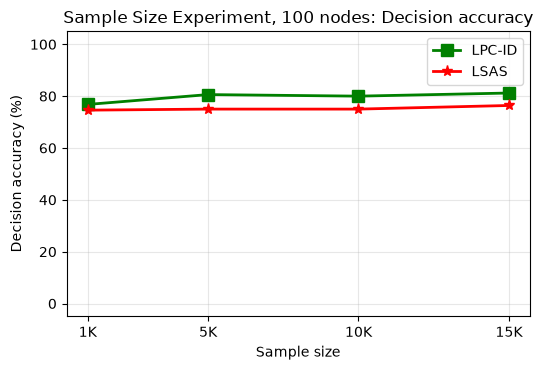

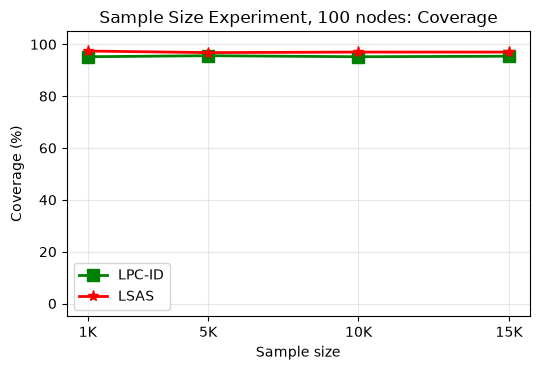

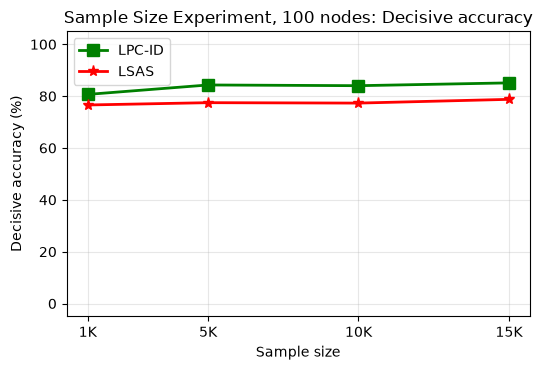

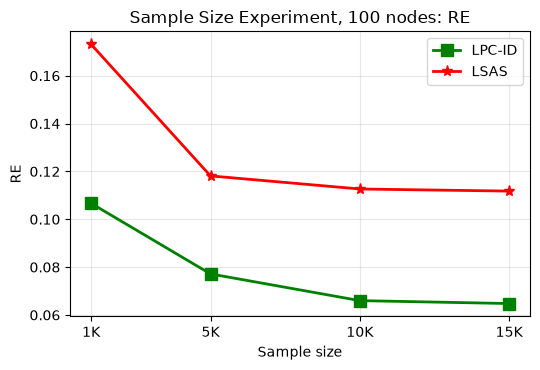

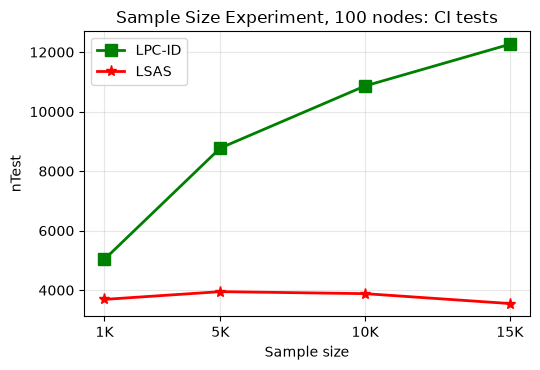

In [33]:
plot_experiment_metrics(
    decision_df=sample_size_base_decision_metrics,
    effect_df=sample_size_base_effect_effort,
    x_col="sample_size",
    x_label="Sample size",
    title_prefix=f"Sample Size Experiment, {BASE_N_OBS} nodes",
)


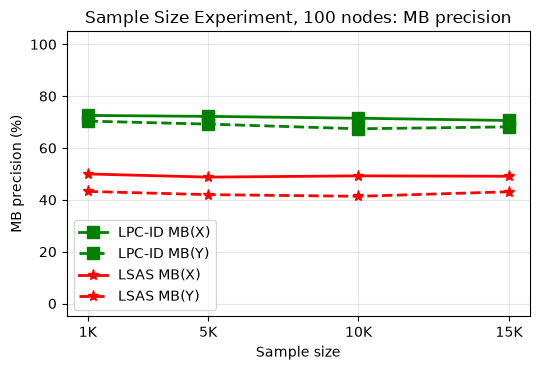

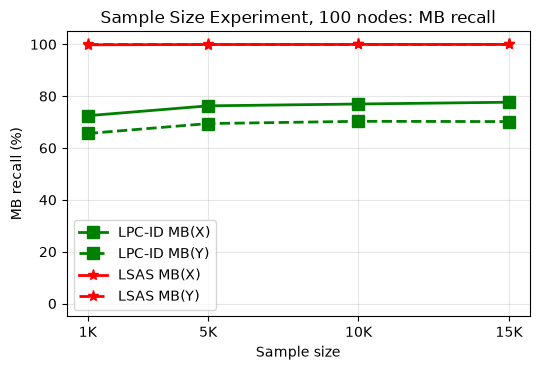

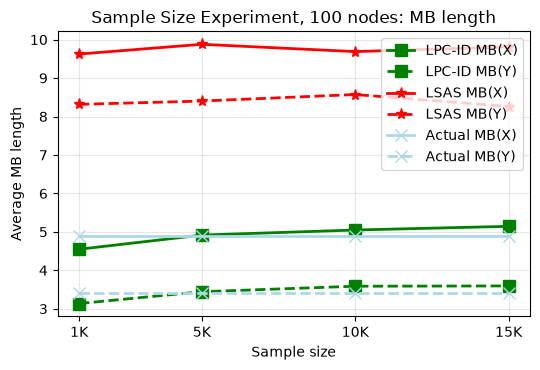

,sample_size,method,target,n_reps,mean_mb_size,std_mb_size,mean_actual_mb_size,std_actual_mb_size,mean_mb_precision,std_mb_precision,mean_mb_recall,std_mb_recall
0,1000,LPC-ID,X,500,4.548,1.802830,4.884,2.748391,0.725604,0.261737,0.724546,0.246032
1,1000,LPC-ID,Y,500,3.136,1.448344,3.420,1.709223,0.703702,0.311076,0.655948,0.307702
2,1000,LSAS,X,500,9.624,3.691867,4.884,2.748391,0.499833,0.204852,0.997990,0.016957
3,1000,LSAS,Y,500,8.316,3.205729,3.420,1.709223,0.432435,0.202066,1.000000,0.000000
4,5000,LPC-ID,X,500,4.916,2.057525,4.884,2.748391,0.721987,0.259121,0.762582,0.223155
5,5000,LPC-ID,Y,500,3.444,1.525621,3.420,1.709223,0.692207,0.306597,0.694179,0.287140
6,5000,LSAS,X,500,9.878,3.655385,4.884,2.748391,0.487699,0.204252,0.999196,0.010452
7,5000,LSAS,Y,500,8.402,3.119593,3.420,1.709223,0.420054,0.188325,1.000000,0.000000
8,10000,LPC-ID,X,500,5.048,2.123845,4.884,2.748391,0.714855,0.265237,0.769697,0.221970
9,10000,LPC-ID,Y,500,3.586,1.504370,3.420,1.709223,0.674122,0.305764,0.702922,0.280370


In [34]:
sample_size_base_mb_comparison, sample_size_base_mb_comparison_detail = compare_markov_blankets(
    sample_size_base_results,
    group_cols=["sample_size"],
)

plot_markov_blanket_metrics(
    sample_size_base_mb_comparison,
    x_col="sample_size",
    x_label="Sample size",
    title_prefix=f"Sample Size Experiment, {BASE_N_OBS} nodes",
)

sample_size_base_mb_comparison


### 250 nodes


In [35]:
BASE_N_OBS = 250
BASE_P = TARGET_AVG_DEGREE / (BASE_N_OBS + 1)

In [36]:
sample_size_base_results = run_structure_experiment(
    structure_name=f"Sample Size Experiment, n_obs = {BASE_N_OBS}...",
    sample_sizes=sample_sizes,
    n_reps=BASE_N_REPS,
    n_obs=BASE_N_OBS,
    p=BASE_P,
    beta=BASE_BETA,
    ci_method=BASE_CI_METHOD,
    max_z_size=MAX_Z_SIZE,
)

sample_size_base_results["sample_experiment_n_obs"] = BASE_N_OBS
sample_size_base_results



Running Sample Size Experiment, n_obs = 250... with sample size 1000 for 500 reps...


Processing Sample Size Experiment, n_obs = 250...:   0%|          | 0/500 [00:00<?, ?it/s]

Processing Sample Size Experiment, n_obs = 250...: 100%|██████████| 500/500 [36:19<00:00,  4.36s/it]  


Running Sample Size Experiment, n_obs = 250... with sample size 5000 for 500 reps...


Processing Sample Size Experiment, n_obs = 250...: 100%|██████████| 500/500 [46:15<00:00,  5.55s/it]  


Running Sample Size Experiment, n_obs = 250... with sample size 10000 for 500 reps...


Processing Sample Size Experiment, n_obs = 250...: 100%|██████████| 500/500 [1:03:53<00:00,  7.67s/it]


Running Sample Size Experiment, n_obs = 250... with sample size 15000 for 500 reps...


Processing Sample Size Experiment, n_obs = 250...: 100%|██████████| 500/500 [1:03:37<00:00,  7.64s/it] 


,method,structure,sample_size,rep,true_decision,decision,decision_correct,is_decisive,true_ce,estimated_ce,...,MB_y,actual_MB_x,actual_MB_y,x_degree,y_degree,avg_xy_degree,p,beta,noise_scale,sample_experiment_n_obs
0,LPC-ID,"Sample Size Experiment, n_obs = 250...",1000,0,+,?,False,False,2.444747,NaN,...,"[V115, V199, V215, V74]","[V115, V199, V215, V64, V74, outcome]","[V115, V199, V215, V64, V74, treatment]",1,6,3.5,0.011952,0,1.0,250
1,LSAS,"Sample Size Experiment, n_obs = 250...",1000,0,+,?,False,False,2.444747,NaN,...,"[V22, V64, V69, V74, V87, V109, V115, V134, V1...","[V115, V199, V215, V64, V74, outcome]","[V115, V199, V215, V64, V74, treatment]",1,6,3.5,0.011952,0,1.0,250
2,LPC-ID,"Sample Size Experiment, n_obs = 250...",1000,1,0,0,True,True,0.000000,0.000000,...,"[V13, V15, V153, V24, V82]","[V11, V217, V74]","[V15, V24]",3,2,2.5,0.011952,0,1.0,250
3,LSAS,"Sample Size Experiment, n_obs = 250...",1000,1,0,0,True,True,0.000000,0.000000,...,"[V7, V9, V10, V15, V24, V37, V47, V56, V62, V7...","[V11, V217, V74]","[V15, V24]",3,2,2.5,0.011952,0,1.0,250
4,LPC-ID,"Sample Size Experiment, n_obs = 250...",1000,2,+,+,True,True,2.082671,2.026412,...,"[V10, V223, V79, V91]","[V10, V133, V223, V229, V79, V91, outcome]","[V10, V223, V79, V91, treatment]",3,5,4.0,0.011952,0,1.0,250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,LSAS,"Sample Size Experiment, n_obs = 250...",15000,497,0,0,True,True,0.000000,0.000000,...,"[V25, V26, V39, V68, V87, V103, V104, V123, V1...","[V112, V145, V29, V64]",[],4,0,2.0,0.011952,0,1.0,250
3996,LPC-ID,"Sample Size Experiment, n_obs = 250...",15000,498,+,+,True,True,2.137658,2.129150,...,"[V193, V231]","[V148, V219, V222, V231, V3, V8, V81, V84, out...","[V222, treatment]",8,2,5.0,0.011952,0,1.0,250
3997,LSAS,"Sample Size Experiment, n_obs = 250...",15000,498,+,+,True,True,2.137658,2.148592,...,"[V0, V14, V24, V38, V77, V79, V90, V110, V126,...","[V148, V219, V222, V231, V3, V8, V81, V84, out...","[V222, treatment]",8,2,5.0,0.011952,0,1.0,250
3998,LPC-ID,"Sample Size Experiment, n_obs = 250...",15000,499,0,0,True,True,0.000000,0.000000,...,"[V118, V247, V32]","[V12, V22, V36]","[V118, V247, V32]",3,3,3.0,0.011952,0,1.0,250


In [37]:
sample_size_base_decision_metrics = (
    sample_size_base_results
    .groupby(["method", "sample_size"], as_index=False)
    .agg(
        decision_acc=("decision_correct", "mean"),
        coverage=("is_decisive", "mean"),
        n_reps=("decision", "size"),
    )
)

sample_size_base_decisive_metrics = (
    sample_size_base_results[sample_size_base_results["is_decisive"]]
    .groupby(["method", "sample_size"], as_index=False)
    .agg(
        decisive_acc=("decision_correct", "mean"),
        n_decisive=("decision", "size"),
    )
)

sample_size_base_decision_metrics = sample_size_base_decision_metrics.merge(
    sample_size_base_decisive_metrics,
    on=["method", "sample_size"],
    how="left",
)

sample_size_base_decision_metrics


,method,sample_size,decision_acc,coverage,n_reps,decisive_acc,n_decisive
0,LPC-ID,1000,0.846,0.978,500,0.865031,489
1,LPC-ID,5000,0.854,0.990,500,0.862626,495
2,LPC-ID,10000,0.878,0.982,500,0.894094,491
3,LPC-ID,15000,0.894,0.984,500,0.908537,492
4,LSAS,1000,0.796,0.980,500,0.812245,490
5,LSAS,5000,0.760,0.986,500,0.770791,493
6,LSAS,10000,0.772,0.980,500,0.787755,490
7,LSAS,15000,0.768,0.976,500,0.786885,488


In [38]:
sample_size_base_effect_effort = (
    sample_size_base_results
    .groupby(["method", "sample_size"], as_index=False)
    .agg(
        mean_RE=("RE", "mean"),
        std_RE=("RE", "std"),
        mean_nTest=("nTest", "mean"),
        std_nTest=("nTest", "std"),
    )
)

sample_size_base_effect_effort


,method,sample_size,mean_RE,std_RE,mean_nTest,std_nTest
0,LPC-ID,1000,0.091281,0.194753,13871.820,14966.953271
1,LPC-ID,5000,0.090386,0.248992,36224.374,127949.467109
2,LPC-ID,10000,0.062048,0.195333,72040.184,507332.319766
3,LPC-ID,15000,0.048677,0.163606,71604.502,439861.984211
4,LSAS,1000,0.129152,0.255930,44238.102,53856.108616
5,LSAS,5000,0.121210,0.264255,42812.662,50440.607871
6,LSAS,10000,0.090848,0.188483,41075.836,44801.639006
7,LSAS,15000,0.078152,0.174351,40956.998,43064.455137


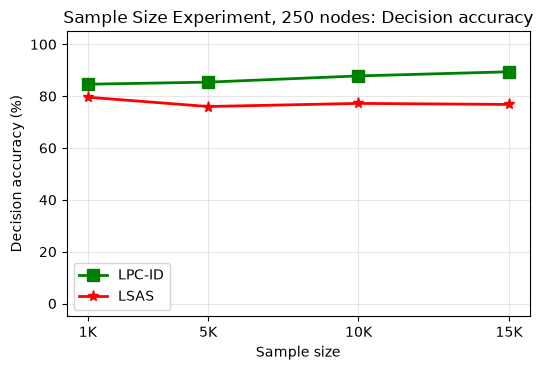

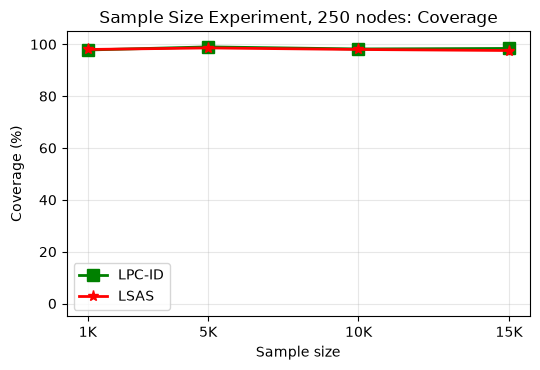

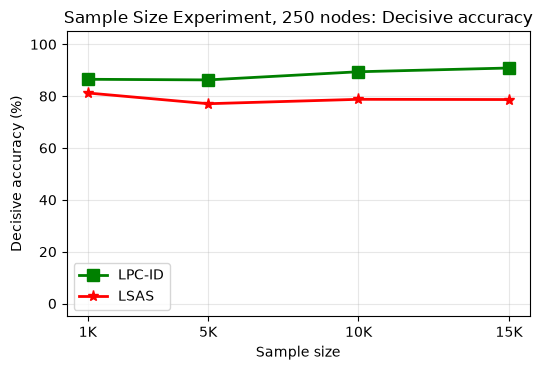

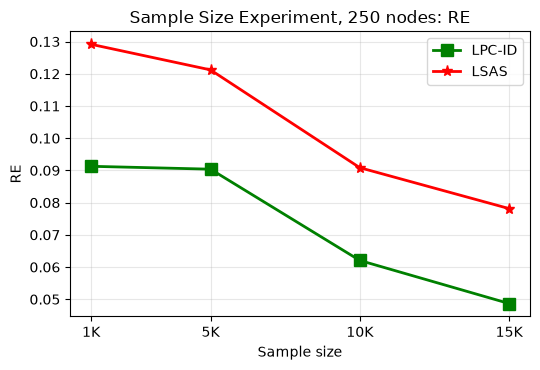

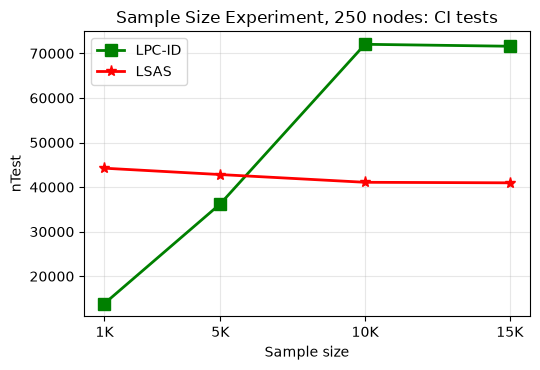

In [39]:
plot_experiment_metrics(
    decision_df=sample_size_base_decision_metrics,
    effect_df=sample_size_base_effect_effort,
    x_col="sample_size",
    x_label="Sample size",
    title_prefix=f"Sample Size Experiment, {BASE_N_OBS} nodes",
)


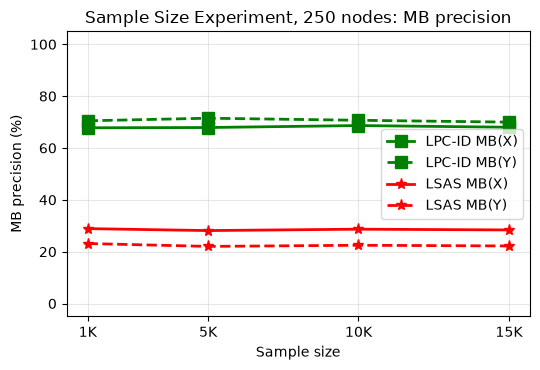

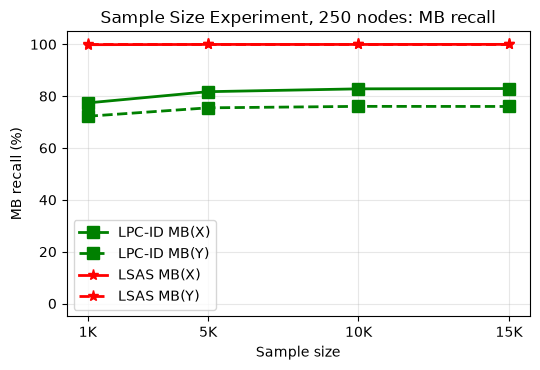

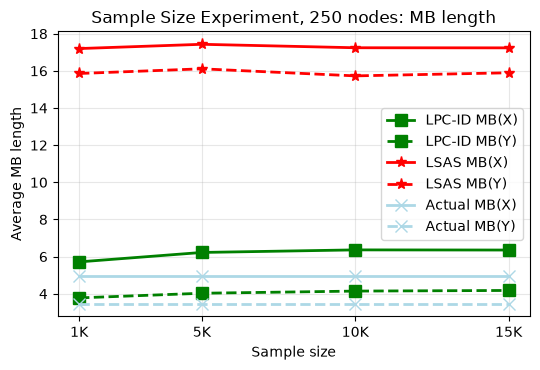

,sample_size,method,target,n_reps,mean_mb_size,std_mb_size,mean_actual_mb_size,std_actual_mb_size,mean_mb_precision,std_mb_precision,mean_mb_recall,std_mb_recall
0,1000,LPC-ID,X,500,5.716,2.722162,4.974,2.956146,0.677940,0.288675,0.773879,0.214041
1,1000,LPC-ID,Y,500,3.778,1.965819,3.474,1.835228,0.704875,0.322309,0.722417,0.274905
2,1000,LSAS,X,500,17.200,5.811329,4.974,2.956146,0.288969,0.150323,0.998460,0.018581
3,1000,LSAS,Y,500,15.858,5.176430,3.474,1.835228,0.231452,0.126667,1.000000,0.000000
4,5000,LPC-ID,X,500,6.224,3.099845,4.974,2.956146,0.678941,0.295308,0.817184,0.187544
5,5000,LPC-ID,Y,500,4.028,2.310388,3.474,1.835228,0.714902,0.320232,0.754925,0.259623
6,5000,LSAS,X,500,17.430,5.337610,4.974,2.956146,0.281431,0.143144,0.999474,0.008227
7,5000,LSAS,Y,500,16.110,4.566794,3.474,1.835228,0.220379,0.109629,1.000000,0.000000
8,10000,LPC-ID,X,500,6.362,3.361183,4.974,2.956146,0.686597,0.297093,0.828127,0.180011
9,10000,LPC-ID,Y,500,4.144,2.521106,3.474,1.835228,0.706911,0.320623,0.760557,0.258423


In [40]:
sample_size_base_mb_comparison, sample_size_base_mb_comparison_detail = compare_markov_blankets(
    sample_size_base_results,
    group_cols=["sample_size"],
)

plot_markov_blanket_metrics(
    sample_size_base_mb_comparison,
    x_col="sample_size",
    x_label="Sample size",
    title_prefix=f"Sample Size Experiment, {BASE_N_OBS} nodes",
)

sample_size_base_mb_comparison


### 400 nodes


In [25]:
BASE_N_OBS = 400
BASE_P = TARGET_AVG_DEGREE / (BASE_N_OBS + 1)

In [26]:
sample_size_alt_nobs_results = run_structure_experiment(
    structure_name=f"Sample Size Experiment, n_obs = {BASE_N_OBS}...",
    sample_sizes=sample_sizes,
    n_reps=BASE_N_REPS,
    n_obs=BASE_N_OBS,
    p=BASE_P,
    beta=BASE_BETA,
    ci_method=BASE_CI_METHOD,
    max_z_size=MAX_Z_SIZE,
)

sample_size_alt_nobs_results["sample_experiment_n_obs"] = BASE_N_OBS
sample_size_alt_nobs_results



Running Sample Size Experiment, n_obs = 400... with sample size 1000 for 200 reps...


Processing Sample Size Experiment, n_obs = 400...: 100%|██████████| 200/200 [57:12<00:00, 17.16s/it] 


Running Sample Size Experiment, n_obs = 400... with sample size 5000 for 200 reps...


Processing Sample Size Experiment, n_obs = 400...: 100%|██████████| 200/200 [1:45:44<00:00, 31.72s/it]   


Running Sample Size Experiment, n_obs = 400... with sample size 10000 for 200 reps...


Processing Sample Size Experiment, n_obs = 400...: 100%|██████████| 200/200 [1:49:32<00:00, 32.86s/it]   


Running Sample Size Experiment, n_obs = 400... with sample size 15000 for 200 reps...


Processing Sample Size Experiment, n_obs = 400...: 100%|██████████| 200/200 [4:26:14<00:00, 79.87s/it]   


,method,structure,sample_size,rep,true_decision,decision,decision_correct,is_decisive,true_ce,estimated_ce,...,MB_y,actual_MB_x,actual_MB_y,x_degree,y_degree,avg_xy_degree,p,beta,noise_scale,sample_experiment_n_obs
0,LPC-ID,"Sample Size Experiment, n_obs = 400...",1000,0,+,+,True,True,2.188035,2.160882,...,"[V302, V322]","[V157, V204, V249, V255, V302, V322, V342, out...","[V302, V322, treatment]",6,3,4.5,0.007481,0,1.0,400
1,LSAS,"Sample Size Experiment, n_obs = 400...",1000,0,+,+,True,True,2.188035,2.125503,...,"[V4, V10, V13, V25, V71, V74, V76, V118, V124,...","[V157, V204, V249, V255, V302, V322, V342, out...","[V302, V322, treatment]",6,3,4.5,0.007481,0,1.0,400
2,LPC-ID,"Sample Size Experiment, n_obs = 400...",1000,1,0,0,True,True,0.000000,0.000000,...,"[V104, V122, V16]","[V154, V278, V280]","[V104, V122, V16]",3,3,3.0,0.007481,0,1.0,400
3,LSAS,"Sample Size Experiment, n_obs = 400...",1000,1,0,0,True,True,0.000000,0.000000,...,"[V1, V16, V53, V56, V73, V74, V77, V80, V99, V...","[V154, V278, V280]","[V104, V122, V16]",3,3,3.0,0.007481,0,1.0,400
4,LPC-ID,"Sample Size Experiment, n_obs = 400...",1000,2,+,+,True,True,2.107793,2.101486,...,[V127],"[V127, outcome]","[V127, treatment]",1,2,1.5,0.007481,0,1.0,400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,LSAS,"Sample Size Experiment, n_obs = 400...",15000,197,0,0,True,True,0.000000,0.000000,...,"[V8, V48, V89, V119, V120, V123, V149, V157, V...","[V305, V6]","[V149, V250]",2,2,2.0,0.007481,0,1.0,400
1596,LPC-ID,"Sample Size Experiment, n_obs = 400...",15000,198,+,+,True,True,1.333938,1.321869,...,"[V224, V264, V328]","[V132, V182, V224, V264, V295, V328, V373, out...","[V224, V264, V328, treatment]",5,4,4.5,0.007481,0,1.0,400
1597,LSAS,"Sample Size Experiment, n_obs = 400...",15000,198,+,+,True,True,1.333938,1.315867,...,"[V34, V45, V57, V61, V67, V69, V74, V79, V82, ...","[V132, V182, V224, V264, V295, V328, V373, out...","[V224, V264, V328, treatment]",5,4,4.5,0.007481,0,1.0,400
1598,LPC-ID,"Sample Size Experiment, n_obs = 400...",15000,199,0,0,True,True,0.000000,0.000000,...,"[V115, V121, V142, V326, V335]",[],"[V115, V142, V326, V335]",0,4,2.0,0.007481,0,1.0,400


In [27]:
sample_size_alt_nobs_decision_metrics = (
    sample_size_alt_nobs_results
    .groupby(["method", "sample_size"], as_index=False)
    .agg(
        decision_acc=("decision_correct", "mean"),
        coverage=("is_decisive", "mean"),
        n_reps=("decision", "size"),
    )
)

sample_size_alt_nobs_decisive_metrics = (
    sample_size_alt_nobs_results[sample_size_alt_nobs_results["is_decisive"]]
    .groupby(["method", "sample_size"], as_index=False)
    .agg(
        decisive_acc=("decision_correct", "mean"),
        n_decisive=("decision", "size"),
    )
)

sample_size_alt_nobs_decision_metrics = sample_size_alt_nobs_decision_metrics.merge(
    sample_size_alt_nobs_decisive_metrics,
    on=["method", "sample_size"],
    how="left",
)

sample_size_alt_nobs_decision_metrics


,method,sample_size,decision_acc,coverage,n_reps,decisive_acc,n_decisive
0,LPC-ID,1000,0.910,0.980,200,0.928571,196
1,LPC-ID,5000,0.890,0.985,200,0.903553,197
2,LPC-ID,10000,0.900,0.985,200,0.913706,197
3,LPC-ID,15000,0.905,0.990,200,0.914141,198
4,LSAS,1000,0.820,0.980,200,0.836735,196
5,LSAS,5000,0.775,0.990,200,0.782828,198
6,LSAS,10000,0.785,0.975,200,0.805128,195
7,LSAS,15000,0.780,0.980,200,0.795918,196


In [28]:
sample_size_alt_nobs_effect_effort = (
    sample_size_alt_nobs_results
    .groupby(["method", "sample_size"], as_index=False)
    .agg(
        mean_RE=("RE", "mean"),
        std_RE=("RE", "std"),
        mean_nTest=("nTest", "mean"),
        std_nTest=("nTest", "std"),
    )
)

sample_size_alt_nobs_effect_effort


,method,sample_size,mean_RE,std_RE,mean_nTest,std_nTest
0,LPC-ID,1000,0.064367,0.170267,32915.370,7.430673e+04
1,LPC-ID,5000,0.063576,0.197274,264433.570,2.219295e+06
2,LPC-ID,10000,0.064615,0.199864,283374.170,1.550763e+06
3,LPC-ID,15000,0.056738,0.197060,968546.050,5.620053e+06
4,LSAS,1000,0.108257,0.197431,191038.675,1.814330e+05
5,LSAS,5000,0.126293,0.257707,171860.465,1.417445e+05
6,LSAS,10000,0.089355,0.188542,169521.815,1.452054e+05
7,LSAS,15000,0.090173,0.204506,164393.945,1.217738e+05


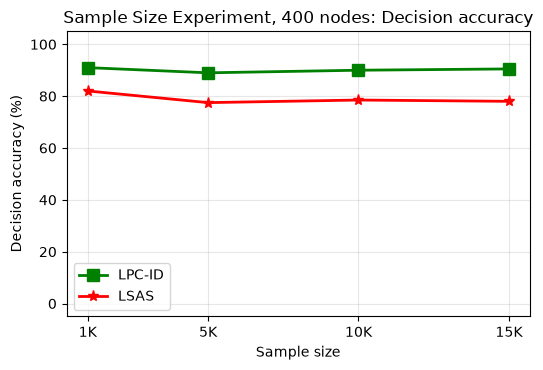

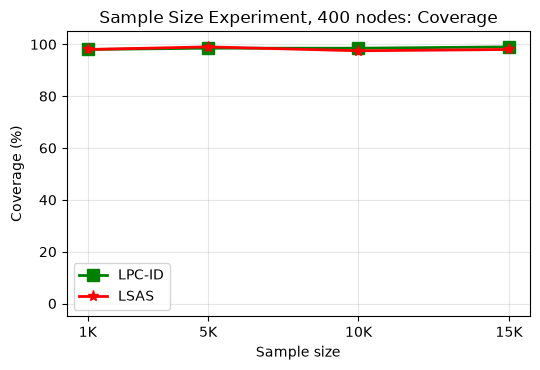

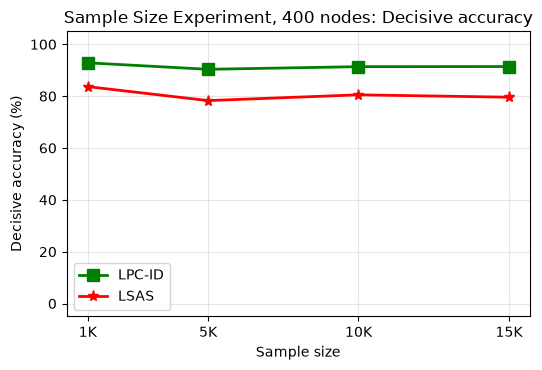

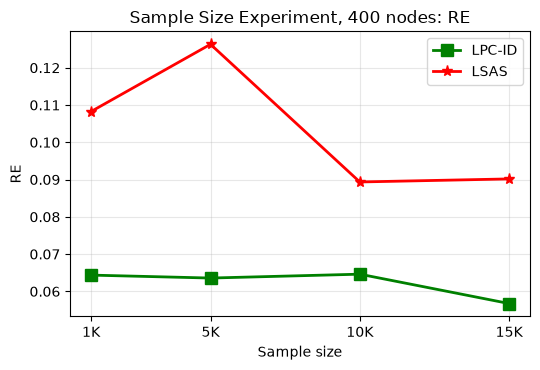

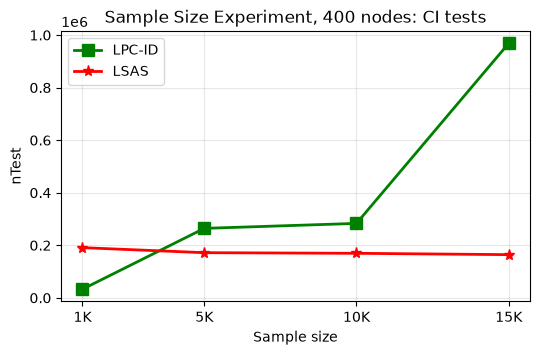

In [29]:
plot_experiment_metrics(
    decision_df=sample_size_alt_nobs_decision_metrics,
    effect_df=sample_size_alt_nobs_effect_effort,
    x_col="sample_size",
    x_label="Sample size",
    title_prefix=f"Sample Size Experiment, {BASE_N_OBS} nodes",
)


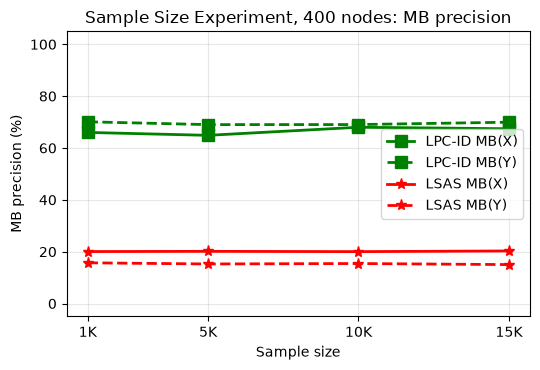

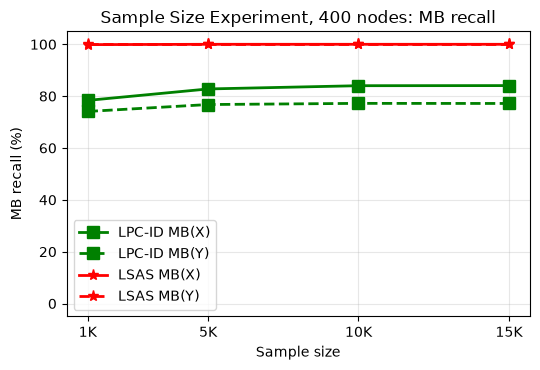

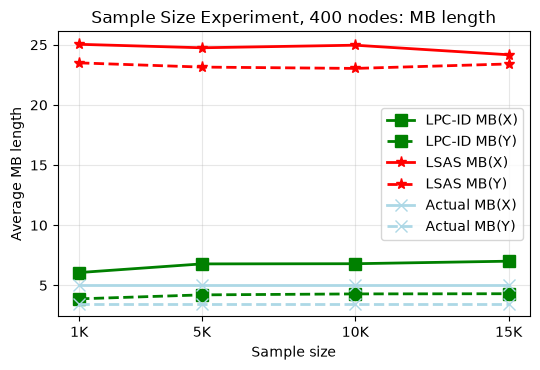

,sample_size,method,target,n_reps,mean_mb_size,std_mb_size,mean_actual_mb_size,std_actual_mb_size,mean_mb_precision,std_mb_precision,mean_mb_recall,std_mb_recall
0,1000,LPC-ID,X,200,6.065,3.181412,4.99,2.882960,0.660033,0.295181,0.783603,0.236220
1,1000,LPC-ID,Y,200,3.880,1.965941,3.49,1.721837,0.701034,0.327947,0.740957,0.299797
2,1000,LSAS,X,200,25.040,6.564592,4.99,2.882960,0.200485,0.112465,0.998718,0.017903
3,1000,LSAS,Y,200,23.495,6.555521,3.49,1.721837,0.157068,0.082463,1.000000,0.000000
4,5000,LPC-ID,X,200,6.785,3.561206,4.99,2.882960,0.648837,0.296648,0.827721,0.195689
5,5000,LPC-ID,Y,200,4.210,2.137462,3.49,1.721837,0.690162,0.320800,0.767617,0.286624
6,5000,LSAS,X,200,24.750,6.107702,4.99,2.882960,0.201336,0.105027,1.000000,0.000000
7,5000,LSAS,Y,200,23.145,5.314621,3.49,1.721837,0.152619,0.072086,1.000000,0.000000
8,10000,LPC-ID,X,200,6.800,3.984896,4.99,2.882960,0.679982,0.296156,0.840277,0.185406
9,10000,LPC-ID,Y,200,4.290,2.367260,3.49,1.721837,0.690363,0.327651,0.772126,0.284479


In [30]:
sample_size_alt_nobs_mb_comparison, sample_size_alt_nobs_mb_comparison_detail = compare_markov_blankets(
    sample_size_alt_nobs_results,
    group_cols=["sample_size"],
)

plot_markov_blanket_metrics(
    sample_size_alt_nobs_mb_comparison,
    x_col="sample_size",
    x_label="Sample size",
    title_prefix=f"Sample Size Experiment, {BASE_N_OBS} nodes",
)

sample_size_alt_nobs_mb_comparison


## Graph Size Experiment


In [31]:
graph_size_results_list = []

for graph_size in graph_sizes:
    results_one_graph_size = run_structure_experiment(
        structure_name=f"Graph size experiment, n_obs={graph_size}",
        sample_sizes=[BASE_SAMPLE_SIZE],
        n_reps=BASE_N_REPS,
        n_obs=graph_size,
        p=p_for_size(graph_size, TARGET_AVG_DEGREE),
        beta=BASE_BETA,
        ci_method=BASE_CI_METHOD,
        max_z_size=MAX_Z_SIZE
        )
    results_one_graph_size["graph_size"] = graph_size
    graph_size_results_list.append(results_one_graph_size)

graph_size_results = pd.concat(graph_size_results_list, ignore_index=True)
graph_size_results



Running Graph size experiment, n_obs=100 with sample size 5000 for 200 reps...


Processing Graph size experiment, n_obs=100: 100%|██████████| 200/200 [03:04<00:00,  1.08it/s]


Running Graph size experiment, n_obs=200 with sample size 5000 for 200 reps...


Processing Graph size experiment, n_obs=200: 100%|██████████| 200/200 [11:09<00:00,  3.35s/it]


Running Graph size experiment, n_obs=300 with sample size 5000 for 200 reps...


Processing Graph size experiment, n_obs=300: 100%|██████████| 200/200 [25:26<00:00,  7.63s/it]


Running Graph size experiment, n_obs=400 with sample size 5000 for 200 reps...


Processing Graph size experiment, n_obs=400: 100%|██████████| 200/200 [1:46:17<00:00, 31.89s/it]   


,method,structure,sample_size,rep,true_decision,decision,decision_correct,is_decisive,true_ce,estimated_ce,...,MB_y,actual_MB_x,actual_MB_y,x_degree,y_degree,avg_xy_degree,p,beta,noise_scale,graph_size
0,LPC-ID,"Graph size experiment, n_obs=100",5000,0,+,+,True,True,2.128573,2.506682,...,"[V42, V56, V78]","[V16, V25, V33, V39, V42, V52, V53, V75, V78, ...","[V33, V42, V52, V78, V9, treatment]",6,6,6.0,0.029703,0,1.0,100
1,LSAS,"Graph size experiment, n_obs=100",5000,0,+,+,True,True,2.128573,3.721895,...,"[V9, V33, V42, V52, V67, V78, V84, V95, V97, t...","[V16, V25, V33, V39, V42, V52, V53, V75, V78, ...","[V33, V42, V52, V78, V9, treatment]",6,6,6.0,0.029703,0,1.0,100
2,LPC-ID,"Graph size experiment, n_obs=100",5000,1,0,0,True,True,0.000000,0.000000,...,"[V46, V49, V67, V69, V70, V74]","[V28, V56, V60, V95]","[V21, V46, V69, V70, V89]",4,5,4.5,0.029703,0,1.0,100
3,LSAS,"Graph size experiment, n_obs=100",5000,1,0,0,True,True,0.000000,0.000000,...,"[V18, V21, V46, V50, V69, V70, V71, V89]","[V28, V56, V60, V95]","[V21, V46, V69, V70, V89]",4,5,4.5,0.029703,0,1.0,100
4,LPC-ID,"Graph size experiment, n_obs=100",5000,2,+,+,True,True,2.560355,2.554776,...,"[V40, V7]","[V40, V7, V87, outcome]","[V40, V7, treatment]",2,3,2.5,0.029703,0,1.0,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,LSAS,"Graph size experiment, n_obs=400",5000,197,0,0,True,True,0.000000,0.000000,...,"[V2, V8, V22, V31, V40, V63, V82, V120, V144, ...","[V305, V6]","[V149, V250]",2,2,2.0,0.007481,0,1.0,400
1596,LPC-ID,"Graph size experiment, n_obs=400",5000,198,+,+,True,True,1.333938,1.331117,...,"[V224, V264, V328]","[V132, V182, V224, V264, V295, V328, V373, out...","[V224, V264, V328, treatment]",5,4,4.5,0.007481,0,1.0,400
1597,LSAS,"Graph size experiment, n_obs=400",5000,198,+,+,True,True,1.333938,1.321579,...,"[V58, V72, V108, V120, V164, V187, V201, V209,...","[V132, V182, V224, V264, V295, V328, V373, out...","[V224, V264, V328, treatment]",5,4,4.5,0.007481,0,1.0,400
1598,LPC-ID,"Graph size experiment, n_obs=400",5000,199,0,0,True,True,0.000000,0.000000,...,"[V115, V142, V326, V335, V388]",[],"[V115, V142, V326, V335]",0,4,2.0,0.007481,0,1.0,400


In [32]:
graph_size_decision_metrics = (
    graph_size_results
    .groupby(["method", "graph_size"], as_index=False)
    .agg(
        decision_acc=("decision_correct", "mean"),
        coverage=("is_decisive", "mean"),
        n_reps=("decision", "size"),
    )
)

graph_size_decisive_metrics = (
    graph_size_results[graph_size_results["is_decisive"]]
    .groupby(["graph_size", "method"], as_index=False)
    .agg(
        decisive_acc=("decision_correct", "mean"),
        n_decisive=("decision", "size"),
    )
)

graph_size_decision_metrics = graph_size_decision_metrics.merge(
    graph_size_decisive_metrics,
    on=["graph_size", "method"],
    how="left",
)

graph_size_decision_metrics["n_decisive"] = graph_size_decision_metrics["n_decisive"].fillna(0).astype(int)

graph_size_decision_metrics


,method,graph_size,decision_acc,coverage,n_reps,decisive_acc,n_decisive
0,LPC-ID,100,0.805,0.950,200,0.847368,190
1,LPC-ID,200,0.805,0.975,200,0.825641,195
2,LPC-ID,300,0.825,0.985,200,0.837563,197
3,LPC-ID,400,0.890,0.985,200,0.903553,197
4,LSAS,100,0.740,0.970,200,0.762887,194
5,LSAS,200,0.705,0.990,200,0.712121,198
6,LSAS,300,0.770,0.995,200,0.773869,199
7,LSAS,400,0.775,0.990,200,0.782828,198


In [33]:
graph_size_effect_effort = (
    graph_size_results
    .groupby(["method", "graph_size"], as_index=False)
    .agg(
        mean_RE=("RE", "mean"),
        std_RE=("RE", "std"),
        mean_nTest=("nTest", "mean"),
        std_nTest=("nTest", "std"),
    )
)

graph_size_effect_effort


,method,graph_size,mean_RE,std_RE,mean_nTest,std_nTest
0,LPC-ID,100,0.071475,0.163165,8544.970,6.244444e+03
1,LPC-ID,200,0.087427,0.224680,25655.630,9.055911e+04
2,LPC-ID,300,0.087497,0.249378,32702.550,5.649350e+04
3,LPC-ID,400,0.063576,0.197274,264433.570,2.219295e+06
4,LSAS,100,0.104005,0.221726,3732.535,4.792870e+03
5,LSAS,200,0.158113,0.271097,22134.530,2.669019e+04
6,LSAS,300,0.108865,0.272246,69721.470,5.773005e+04
7,LSAS,400,0.126293,0.257707,171860.465,1.417445e+05


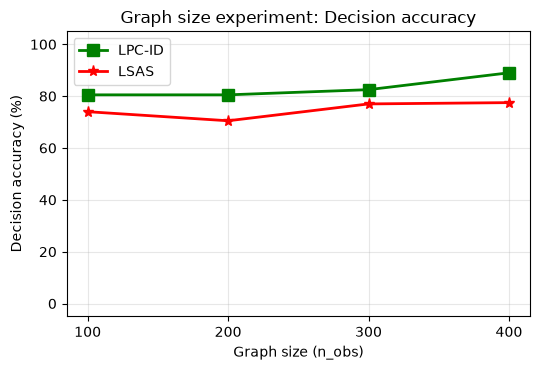

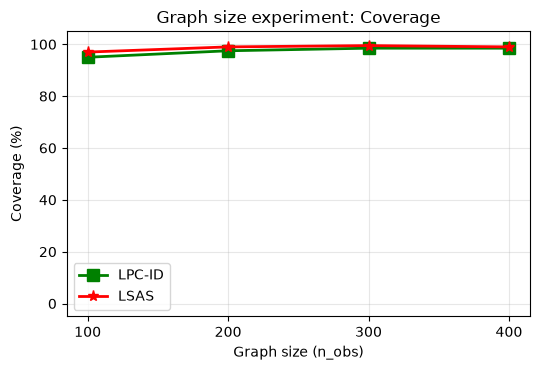

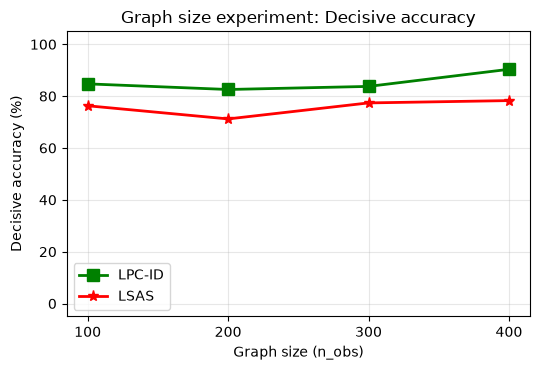

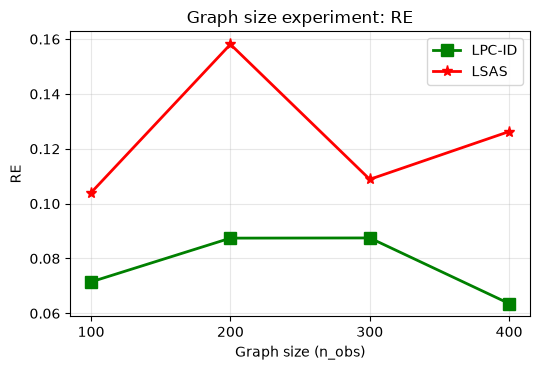

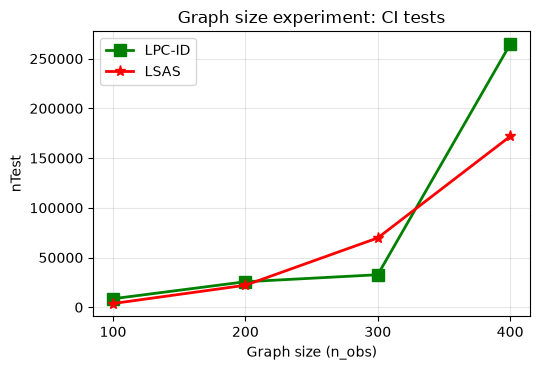

In [34]:
plot_experiment_metrics(
    decision_df=graph_size_decision_metrics,
    effect_df=graph_size_effect_effort,
    x_col="graph_size",
    x_label="Graph size (n_obs)",
    title_prefix="Graph size experiment",
)


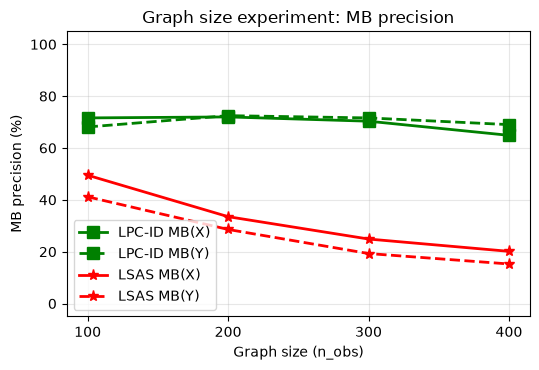

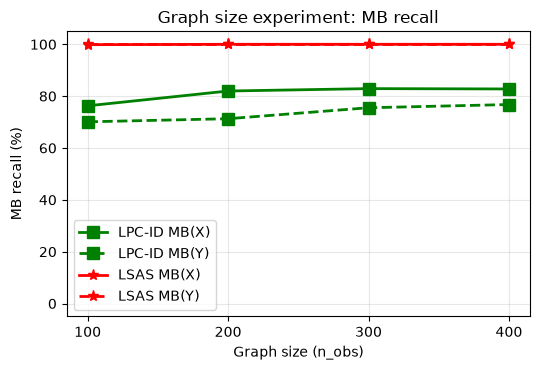

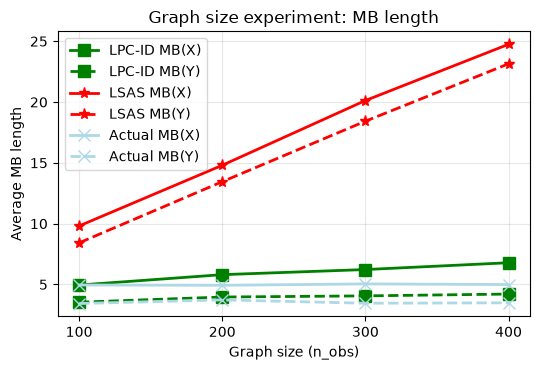

,graph_size,method,target,n_reps,mean_mb_size,std_mb_size,mean_actual_mb_size,std_actual_mb_size,mean_mb_precision,std_mb_precision,mean_mb_recall,std_mb_recall
0,100,LPC-ID,X,200,4.950,2.031783,4.955,2.778774,0.716025,0.248507,0.762673,0.217917
1,100,LPC-ID,Y,200,3.540,1.590929,3.430,1.819796,0.681144,0.314547,0.700960,0.289203
2,100,LSAS,X,200,9.810,3.568976,4.955,2.778774,0.495016,0.196628,0.998512,0.014844
3,100,LSAS,Y,200,8.420,3.084016,3.430,1.819796,0.411720,0.187494,1.000000,0.000000
4,200,LPC-ID,X,200,5.805,3.205989,4.930,2.855850,0.719846,0.277548,0.819777,0.197091
5,200,LPC-ID,Y,200,3.965,2.099001,3.730,1.831357,0.724758,0.299529,0.712947,0.268176
6,200,LSAS,X,200,14.800,4.849494,4.930,2.855850,0.335104,0.175617,1.000000,0.000000
7,200,LSAS,Y,200,13.450,4.230483,3.730,1.831357,0.285769,0.138797,1.000000,0.000000
8,300,LPC-ID,X,200,6.225,2.823871,5.045,2.816494,0.703348,0.289156,0.829016,0.165102
9,300,LPC-ID,Y,200,4.060,2.254287,3.455,1.655803,0.715979,0.301915,0.755232,0.250205


In [35]:
graph_size_mb_comparison, graph_size_mb_comparison_detail = compare_markov_blankets(
    graph_size_results,
    group_cols=["graph_size"],
)

plot_markov_blanket_metrics(
    graph_size_mb_comparison,
    x_col="graph_size",
    x_label="Graph size (n_obs)",
    title_prefix="Graph size experiment",
)

graph_size_mb_comparison


## Average Degree Experiment


### 100 Nodes

In [36]:
BASE_N_OBS = 100

In [37]:
avg_degree_results_list = []

for avg_degree in avg_degrees:
    results_one_avg_degree = run_structure_experiment(
        structure_name=f"Average degree experiment, avg_degree={avg_degree}",
        sample_sizes=[BASE_SAMPLE_SIZE],
        n_reps=BASE_N_REPS,
        n_obs=BASE_N_OBS,
        p=p_for_size(BASE_N_OBS, avg_degree=avg_degree),
        beta=BASE_BETA,
        ci_method=BASE_CI_METHOD,
        max_z_size=MAX_Z_SIZE
        )
    results_one_avg_degree["avg_degree"] = avg_degree
    avg_degree_results_list.append(results_one_avg_degree)

avg_degree_results = pd.concat(avg_degree_results_list, ignore_index=True)
avg_degree_results



Running Average degree experiment, avg_degree=3 with sample size 5000 for 200 reps...


Processing Average degree experiment, avg_degree=3: 100%|██████████| 200/200 [03:03<00:00,  1.09it/s]


Running Average degree experiment, avg_degree=4 with sample size 5000 for 200 reps...


Processing Average degree experiment, avg_degree=4: 100%|██████████| 200/200 [05:03<00:00,  1.52s/it]


Running Average degree experiment, avg_degree=5 with sample size 5000 for 200 reps...


Processing Average degree experiment, avg_degree=5: 100%|██████████| 200/200 [06:19<00:00,  1.90s/it]


Running Average degree experiment, avg_degree=6 with sample size 5000 for 200 reps...


Processing Average degree experiment, avg_degree=6: 100%|██████████| 200/200 [07:09<00:00,  2.15s/it]


,method,structure,sample_size,rep,true_decision,decision,decision_correct,is_decisive,true_ce,estimated_ce,...,MB_y,actual_MB_x,actual_MB_y,x_degree,y_degree,avg_xy_degree,p,beta,noise_scale,avg_degree
0,LPC-ID,"Average degree experiment, avg_degree=3",5000,0,+,+,True,True,2.128573,2.506682,...,"[V42, V56, V78]","[V16, V25, V33, V39, V42, V52, V53, V75, V78, ...","[V33, V42, V52, V78, V9, treatment]",6,6,6.0,0.029703,0,1.0,3
1,LSAS,"Average degree experiment, avg_degree=3",5000,0,+,+,True,True,2.128573,3.721895,...,"[V9, V33, V42, V52, V67, V78, V84, V95, V97, t...","[V16, V25, V33, V39, V42, V52, V53, V75, V78, ...","[V33, V42, V52, V78, V9, treatment]",6,6,6.0,0.029703,0,1.0,3
2,LPC-ID,"Average degree experiment, avg_degree=3",5000,1,0,0,True,True,0.000000,0.000000,...,"[V46, V49, V67, V69, V70, V74]","[V28, V56, V60, V95]","[V21, V46, V69, V70, V89]",4,5,4.5,0.029703,0,1.0,3
3,LSAS,"Average degree experiment, avg_degree=3",5000,1,0,0,True,True,0.000000,0.000000,...,"[V18, V21, V46, V50, V69, V70, V71, V89]","[V28, V56, V60, V95]","[V21, V46, V69, V70, V89]",4,5,4.5,0.029703,0,1.0,3
4,LPC-ID,"Average degree experiment, avg_degree=3",5000,2,+,+,True,True,2.560355,2.554776,...,"[V40, V7]","[V40, V7, V87, outcome]","[V40, V7, treatment]",2,3,2.5,0.029703,0,1.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,LSAS,"Average degree experiment, avg_degree=6",5000,197,0,+,False,True,0.000000,0.550018,...,"[V2, V4, V10, V20, V39, V70, V72]","[V44, V57, V63, V69, V8, V87]","[V10, V2, V20, V39, V70]",6,5,5.5,0.059406,0,1.0,6
1596,LPC-ID,"Average degree experiment, avg_degree=6",5000,198,+,+,True,True,1.289219,1.344120,...,"[V17, V18, V58, V98]","[V17, V25, V36, V37, V45, V47, V53, V56, V6, V...","[V17, V25, V36, V37, V45, V47, V53, V71, V91, ...",5,11,8.0,0.059406,0,1.0,6
1597,LSAS,"Average degree experiment, avg_degree=6",5000,198,+,+,True,True,1.289219,2.964980,...,"[V6, V17, V23, V25, V33, V36, V37, V38, V42, V...","[V17, V25, V36, V37, V45, V47, V53, V56, V6, V...","[V17, V25, V36, V37, V45, V47, V53, V71, V91, ...",5,11,8.0,0.059406,0,1.0,6
1598,LPC-ID,"Average degree experiment, avg_degree=6",5000,199,0,?,False,False,0.000000,NaN,...,"[V0, V17, V21, V79]","[V0, V11, V15, V4, V40, V58, V6, V78]","[V0, V12, V28, V44, V59, V73, V79]",8,7,7.5,0.059406,0,1.0,6


In [38]:
avg_degree_decision_metrics = (
    avg_degree_results
    .groupby(["method", "avg_degree"], as_index=False)
    .agg(
        decision_acc=("decision_correct", "mean"),
        coverage=("is_decisive", "mean"),
        n_reps=("decision", "size"),
    )
)

avg_degree_decisive_metrics = (
    avg_degree_results[avg_degree_results["is_decisive"]]
    .groupby(["method", "avg_degree"], as_index=False)
    .agg(
        decisive_acc=("decision_correct", "mean"),
        n_decisive=("decision", "size"),
    )
)

avg_degree_decision_metrics = avg_degree_decision_metrics.merge(
    avg_degree_decisive_metrics,
    on=["method", "avg_degree"],
    how="left",
)

avg_degree_decision_metrics


,method,avg_degree,decision_acc,coverage,n_reps,decisive_acc,n_decisive
0,LPC-ID,3,0.805,0.950,200,0.847368,190
1,LPC-ID,4,0.600,0.885,200,0.677966,177
2,LPC-ID,5,0.410,0.820,200,0.500000,164
3,LPC-ID,6,0.355,0.760,200,0.467105,152
4,LSAS,3,0.740,0.970,200,0.762887,194
5,LSAS,4,0.590,0.980,200,0.602041,196
6,LSAS,5,0.515,0.995,200,0.517588,199
7,LSAS,6,0.510,1.000,200,0.510000,200


In [39]:
avg_degree_effect_effort = (
    avg_degree_results
    .groupby(["method", "avg_degree"], as_index=False)
    .agg(
        mean_RE=("RE", "mean"),
        std_RE=("RE", "std"),
        mean_nTest=("nTest", "mean"),
        std_nTest=("nTest", "std"),
    )
)

avg_degree_effect_effort


,method,avg_degree,mean_RE,std_RE,mean_nTest,std_nTest
0,LPC-ID,3,0.071475,0.163165,8544.970,6244.443721
1,LPC-ID,4,0.180388,0.271164,17989.305,8336.144294
2,LPC-ID,5,0.397721,0.502093,22070.960,6667.174192
3,LPC-ID,6,0.587496,0.968467,23328.815,4969.010918
4,LSAS,3,0.104005,0.221726,3732.535,4792.870422
5,LSAS,4,0.373532,0.561273,5246.290,6187.495285
6,LSAS,5,0.660184,1.075322,7908.045,9322.355126
7,LSAS,6,0.823859,1.095214,11964.015,19019.276072


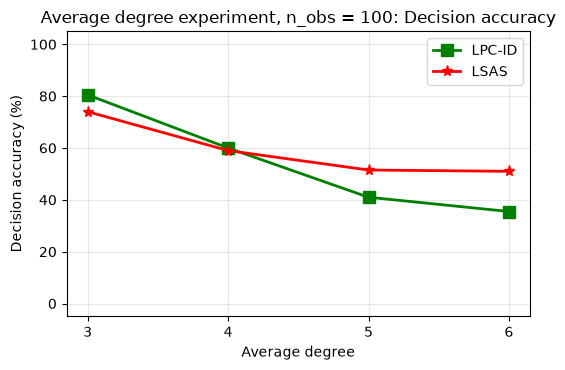

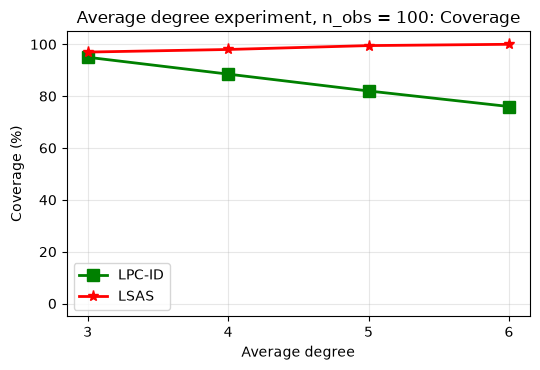

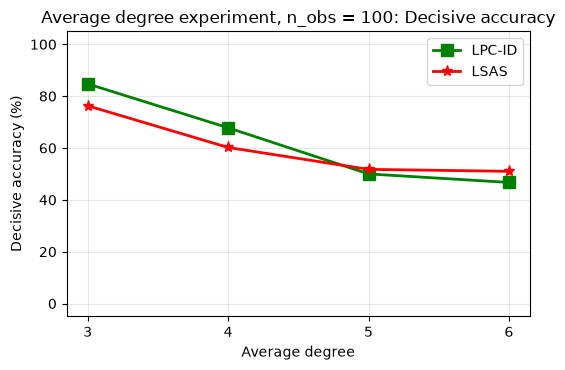

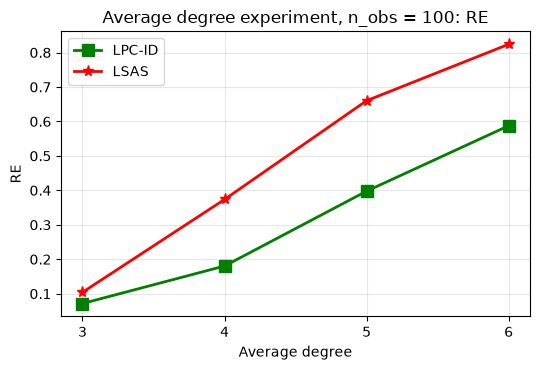

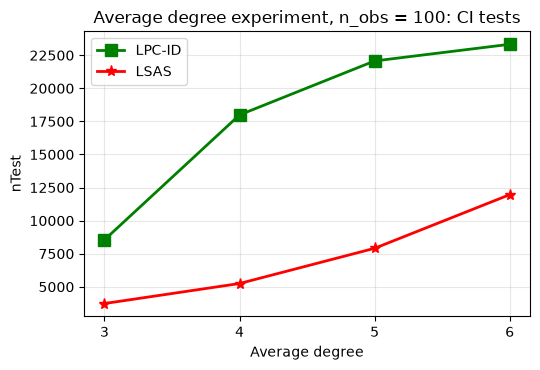

In [40]:
plot_experiment_metrics(
    decision_df=avg_degree_decision_metrics,
    effect_df=avg_degree_effect_effort,
    x_col="avg_degree",
    x_label="Average degree",
    title_prefix=f"Average degree experiment, n_obs = {BASE_N_OBS}",
)


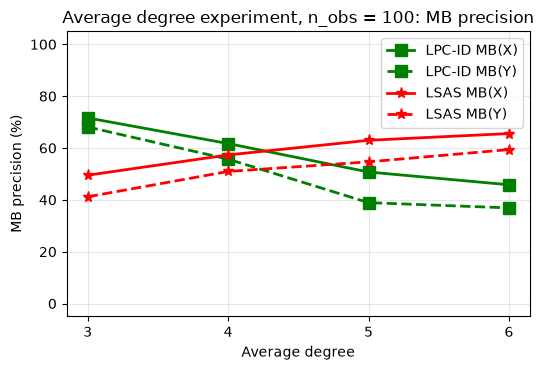

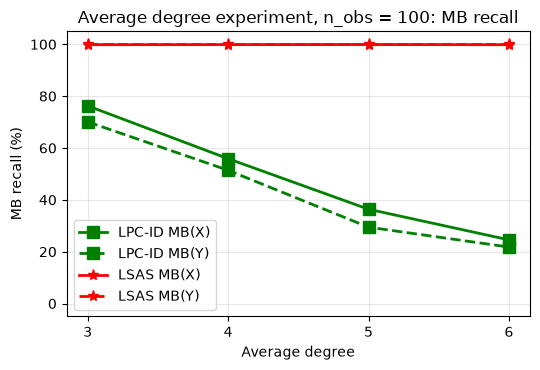

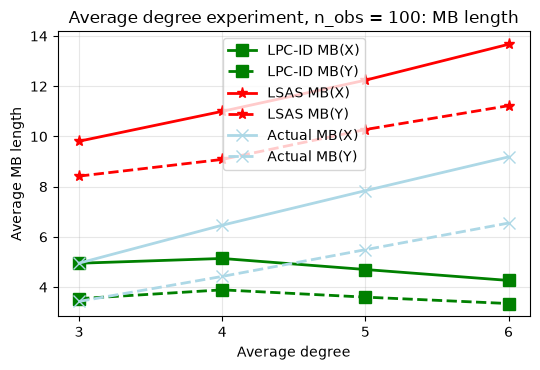

,avg_degree,method,target,n_reps,mean_mb_size,std_mb_size,mean_actual_mb_size,std_actual_mb_size,mean_mb_precision,std_mb_precision,mean_mb_recall,std_mb_recall
0,3,LPC-ID,X,200,4.950,2.031783,4.955,2.778774,0.716025,0.248507,0.762673,0.217917
1,3,LPC-ID,Y,200,3.540,1.590929,3.430,1.819796,0.681144,0.314547,0.700960,0.289203
2,3,LSAS,X,200,9.810,3.568976,4.955,2.778774,0.495016,0.196628,0.998512,0.014844
3,3,LSAS,Y,200,8.420,3.084016,3.430,1.819796,0.411720,0.187494,1.000000,0.000000
4,4,LPC-ID,X,200,5.140,2.340468,6.465,3.541396,0.617123,0.258134,0.558776,0.293701
5,4,LPC-ID,Y,200,3.890,1.574897,4.425,2.026055,0.556962,0.296987,0.513971,0.297199
6,4,LSAS,X,200,11.000,4.054900,6.465,3.541396,0.573227,0.206348,0.998692,0.010665
7,4,LSAS,Y,200,9.085,3.141196,4.425,2.026055,0.509451,0.203545,1.000000,0.000000
8,5,LPC-ID,X,200,4.700,1.902128,7.840,3.755652,0.507314,0.261760,0.363774,0.266578
9,5,LPC-ID,Y,200,3.600,1.414214,5.490,2.250606,0.389190,0.274548,0.294588,0.252002


In [41]:
avg_degree_mb_comparison, avg_degree_mb_comparison_detail = compare_markov_blankets(
    avg_degree_results,
    group_cols=["avg_degree"],
)

plot_markov_blanket_metrics(
    avg_degree_mb_comparison,
    x_col="avg_degree",
    x_label="Average degree",
    title_prefix=f"Average degree experiment, n_obs = {BASE_N_OBS}",
)

avg_degree_mb_comparison


### 250 Nodes

In [42]:
BASE_N_REPS = 200
BASE_N_OBS = 250

In [43]:
avg_degree_results_list = []

for avg_degree in avg_degrees:
    results_one_avg_degree = run_structure_experiment(
        structure_name=f"Average degree experiment, avg_degree={avg_degree}",
        sample_sizes=[BASE_SAMPLE_SIZE],
        n_reps=BASE_N_REPS,
        n_obs=BASE_N_OBS,
        p=p_for_size(BASE_N_OBS, avg_degree=avg_degree),
        beta=BASE_BETA,
        ci_method=BASE_CI_METHOD,
        max_z_size=MAX_Z_SIZE
        )
    results_one_avg_degree["avg_degree"] = avg_degree
    avg_degree_results_list.append(results_one_avg_degree)

avg_degree_results = pd.concat(avg_degree_results_list, ignore_index=True)
avg_degree_results



Running Average degree experiment, avg_degree=3 with sample size 5000 for 200 reps...


Processing Average degree experiment, avg_degree=3: 100%|██████████| 200/200 [18:16<00:00,  5.48s/it]  


Running Average degree experiment, avg_degree=4 with sample size 5000 for 200 reps...


Processing Average degree experiment, avg_degree=4: 100%|██████████| 200/200 [23:33<00:00,  7.07s/it]


Running Average degree experiment, avg_degree=5 with sample size 5000 for 200 reps...


Processing Average degree experiment, avg_degree=5: 100%|██████████| 200/200 [32:02<00:00,  9.61s/it]


Running Average degree experiment, avg_degree=6 with sample size 5000 for 200 reps...


Processing Average degree experiment, avg_degree=6: 100%|██████████| 200/200 [31:35<00:00,  9.48s/it]


,method,structure,sample_size,rep,true_decision,decision,decision_correct,is_decisive,true_ce,estimated_ce,...,MB_y,actual_MB_x,actual_MB_y,x_degree,y_degree,avg_xy_degree,p,beta,noise_scale,avg_degree
0,LPC-ID,"Average degree experiment, avg_degree=3",5000,0,+,?,False,False,2.444747,NaN,...,"[V115, V199, V215, V64, V74]","[V115, V199, V215, V64, V74, outcome]","[V115, V199, V215, V64, V74, treatment]",1,6,3.5,0.011952,0,1.0,3
1,LSAS,"Average degree experiment, avg_degree=3",5000,0,+,?,False,False,2.444747,NaN,...,"[V34, V36, V38, V55, V56, V64, V74, V115, V148...","[V115, V199, V215, V64, V74, outcome]","[V115, V199, V215, V64, V74, treatment]",1,6,3.5,0.011952,0,1.0,3
2,LPC-ID,"Average degree experiment, avg_degree=3",5000,1,0,0,True,True,0.000000,0.000000,...,"[V15, V24]","[V11, V217, V74]","[V15, V24]",3,2,2.5,0.011952,0,1.0,3
3,LSAS,"Average degree experiment, avg_degree=3",5000,1,0,0,True,True,0.000000,0.000000,...,"[V15, V24, V44, V66, V87, V91, V109, V112, V11...","[V11, V217, V74]","[V15, V24]",3,2,2.5,0.011952,0,1.0,3
4,LPC-ID,"Average degree experiment, avg_degree=3",5000,2,+,+,True,True,2.082671,2.053720,...,"[V10, V223, V79, V91]","[V10, V133, V223, V229, V79, V91, outcome]","[V10, V223, V79, V91, treatment]",3,5,4.0,0.011952,0,1.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,LSAS,"Average degree experiment, avg_degree=6",5000,197,0,+,False,True,0.000000,0.330744,...,"[V6, V38, V63, V77, V120, V135, V160, V172, V2...","[V119, V13, V74, V76]","[V135, V160, V241, V242, V77]",4,5,4.5,0.023904,0,1.0,6
1596,LPC-ID,"Average degree experiment, avg_degree=6",5000,198,+,?,False,False,2.093064,NaN,...,[V229],"[V164, V171, V246, V30, V33, V74, V91, outcome]","[V164, V171, V30, V33, V91, treatment]",3,6,4.5,0.023904,0,1.0,6
1597,LSAS,"Average degree experiment, avg_degree=6",5000,198,+,+,True,True,2.093064,6.180144,...,"[V11, V19, V25, V29, V30, V33, V83, V88, V91, ...","[V164, V171, V246, V30, V33, V74, V91, outcome]","[V164, V171, V30, V33, V91, treatment]",3,6,4.5,0.023904,0,1.0,6
1598,LPC-ID,"Average degree experiment, avg_degree=6",5000,199,0,+,False,True,0.000000,0.327662,...,"[V136, V232, V240, V247, V42]","[V107, V133, V169, V24, V49]","[V129, V136, V183, V191, V205, V210, V247, V26]",5,8,6.5,0.023904,0,1.0,6


In [44]:
avg_degree_decision_metrics = (
    avg_degree_results
    .groupby(["method", "avg_degree"], as_index=False)
    .agg(
        decision_acc=("decision_correct", "mean"),
        coverage=("is_decisive", "mean"),
        n_reps=("decision", "size"),
    )
)

avg_degree_decisive_metrics = (
    avg_degree_results[avg_degree_results["is_decisive"]]
    .groupby(["method", "avg_degree"], as_index=False)
    .agg(
        decisive_acc=("decision_correct", "mean"),
        n_decisive=("decision", "size"),
    )
)

avg_degree_decision_metrics = avg_degree_decision_metrics.merge(
    avg_degree_decisive_metrics,
    on=["method", "avg_degree"],
    how="left",
)

avg_degree_decision_metrics


,method,avg_degree,decision_acc,coverage,n_reps,decisive_acc,n_decisive
0,LPC-ID,3,0.850,0.980,200,0.867347,196
1,LPC-ID,4,0.655,0.980,200,0.668367,196
2,LPC-ID,5,0.475,0.915,200,0.519126,183
3,LPC-ID,6,0.430,0.855,200,0.502924,171
4,LSAS,3,0.760,0.985,200,0.771574,197
5,LSAS,4,0.575,1.000,200,0.575000,200
6,LSAS,5,0.520,1.000,200,0.520000,200
7,LSAS,6,0.500,1.000,200,0.500000,200


In [45]:
avg_degree_effect_effort = (
    avg_degree_results
    .groupby(["method", "avg_degree"], as_index=False)
    .agg(
        mean_RE=("RE", "mean"),
        std_RE=("RE", "std"),
        mean_nTest=("nTest", "mean"),
        std_nTest=("nTest", "std"),
    )
)

avg_degree_effect_effort


,method,avg_degree,mean_RE,std_RE,mean_nTest,std_nTest
0,LPC-ID,3,0.081527,0.212640,36147.250,169269.366204
1,LPC-ID,4,0.111816,0.194114,54290.040,26384.929671
2,LPC-ID,5,0.182107,0.250933,76773.600,27404.847801
3,LPC-ID,6,0.308355,0.386826,77994.410,22130.090281
4,LSAS,3,0.136638,0.309086,40395.555,44119.260705
5,LSAS,4,0.270164,0.385262,50338.505,46466.171989
6,LSAS,5,0.392869,0.633694,70813.560,79277.625181
7,LSAS,6,0.748729,0.852733,67998.950,66350.275169


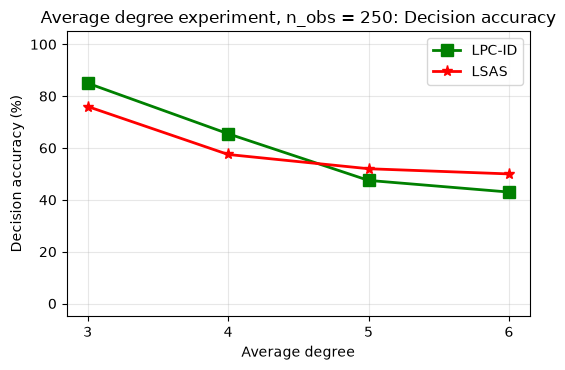

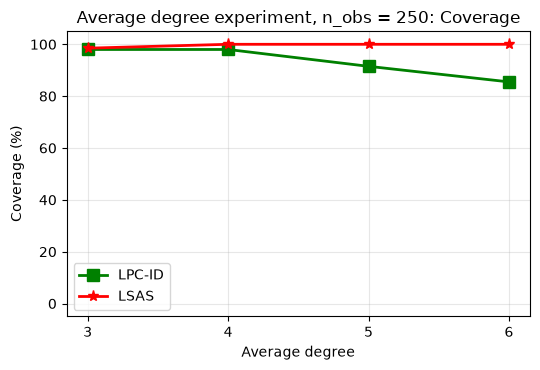

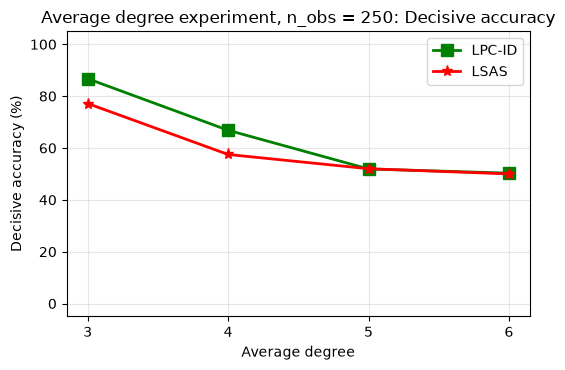

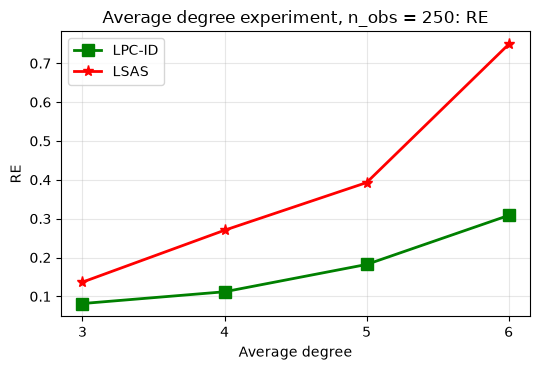

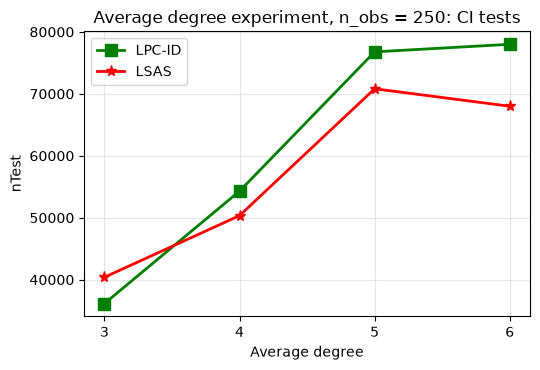

In [46]:
plot_experiment_metrics(
    decision_df=avg_degree_decision_metrics,
    effect_df=avg_degree_effect_effort,
    x_col="avg_degree",
    x_label="Average degree",
    title_prefix=f"Average degree experiment, n_obs = {BASE_N_OBS}",
)


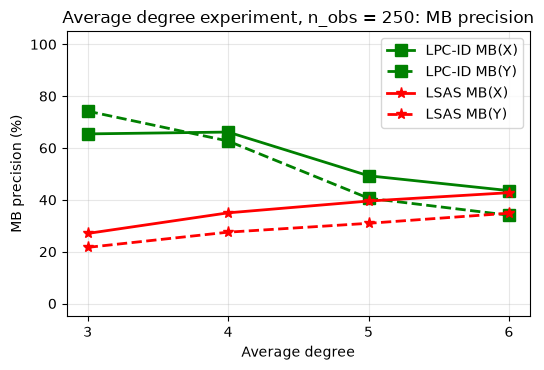

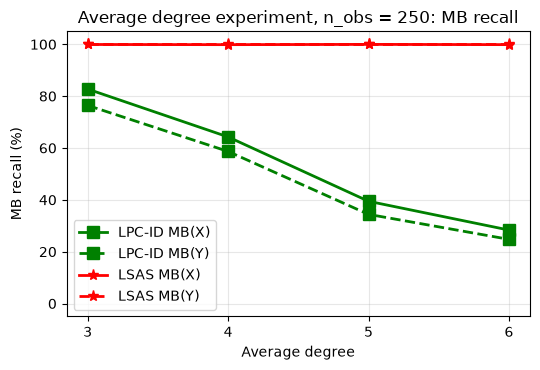

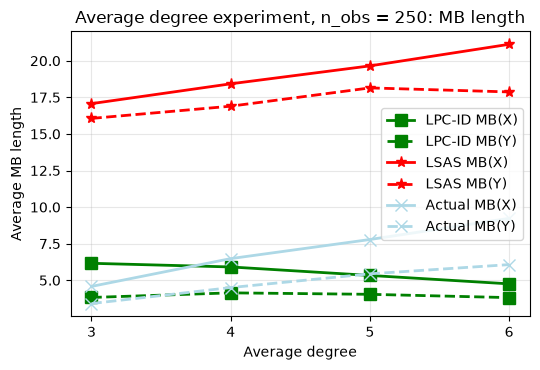

,avg_degree,method,target,n_reps,mean_mb_size,std_mb_size,mean_actual_mb_size,std_actual_mb_size,mean_mb_precision,std_mb_precision,mean_mb_recall,std_mb_recall
0,3,LPC-ID,X,200,6.160,3.143854,4.580,2.692554,0.654340,0.300296,0.827330,0.184961
1,3,LPC-ID,Y,200,3.825,1.991029,3.410,1.751353,0.742139,0.306881,0.764255,0.243440
2,3,LSAS,X,200,17.070,5.046029,4.580,2.692554,0.270357,0.145383,0.999264,0.010257
3,3,LSAS,Y,200,16.060,4.424282,3.410,1.751353,0.216620,0.103640,1.000000,0.000000
4,4,LPC-ID,X,200,5.910,2.597235,6.480,3.256165,0.661457,0.257246,0.642679,0.264753
5,4,LPC-ID,Y,200,4.140,1.701433,4.500,1.853965,0.626888,0.315034,0.586705,0.312136
6,4,LSAS,X,200,18.425,5.003956,6.480,3.256165,0.349841,0.154782,0.998604,0.014166
7,4,LSAS,Y,200,16.895,4.536172,4.500,1.853965,0.275278,0.112073,1.000000,0.000000
8,5,LPC-ID,X,200,5.330,2.338470,7.785,3.972111,0.492853,0.252501,0.394499,0.274007
9,5,LPC-ID,Y,200,4.040,1.603514,5.440,2.229631,0.406265,0.283075,0.344022,0.280695


In [47]:
avg_degree_mb_comparison, avg_degree_mb_comparison_detail = compare_markov_blankets(
    avg_degree_results,
    group_cols=["avg_degree"],
)

plot_markov_blanket_metrics(
    avg_degree_mb_comparison,
    x_col="avg_degree",
    x_label="Average degree",
    title_prefix=f"Average degree experiment, n_obs = {BASE_N_OBS}",
)

avg_degree_mb_comparison


### 400 Nodes

In [48]:
BASE_N_OBS = 400

In [49]:
avg_degree_results_list = []

for avg_degree in avg_degrees:
    results_one_avg_degree = run_structure_experiment(
        structure_name=f"Average degree experiment, avg_degree={avg_degree}",
        sample_sizes=[BASE_SAMPLE_SIZE],
        n_reps=BASE_N_REPS,
        n_obs=BASE_N_OBS,
        p=p_for_size(BASE_N_OBS, avg_degree=avg_degree),
        beta=BASE_BETA,
        ci_method=BASE_CI_METHOD,
        max_z_size=MAX_Z_SIZE
        )
    results_one_avg_degree["avg_degree"] = avg_degree
    avg_degree_results_list.append(results_one_avg_degree)

avg_degree_results = pd.concat(avg_degree_results_list, ignore_index=True)
avg_degree_results



Running Average degree experiment, avg_degree=3 with sample size 5000 for 200 reps...


Processing Average degree experiment, avg_degree=3: 100%|██████████| 200/200 [1:45:55<00:00, 31.78s/it]   


Running Average degree experiment, avg_degree=4 with sample size 5000 for 200 reps...


Processing Average degree experiment, avg_degree=4: 100%|██████████| 200/200 [1:24:06<00:00, 25.23s/it]   


Running Average degree experiment, avg_degree=5 with sample size 5000 for 200 reps...


Processing Average degree experiment, avg_degree=5: 100%|██████████| 200/200 [1:39:26<00:00, 29.83s/it]


Running Average degree experiment, avg_degree=6 with sample size 5000 for 200 reps...


Processing Average degree experiment, avg_degree=6: 100%|██████████| 200/200 [1:46:49<00:00, 32.05s/it]


,method,structure,sample_size,rep,true_decision,decision,decision_correct,is_decisive,true_ce,estimated_ce,...,MB_y,actual_MB_x,actual_MB_y,x_degree,y_degree,avg_xy_degree,p,beta,noise_scale,avg_degree
0,LPC-ID,"Average degree experiment, avg_degree=3",5000,0,+,+,True,True,2.188035,2.169917,...,"[V302, V322]","[V157, V204, V249, V255, V302, V322, V342, out...","[V302, V322, treatment]",6,3,4.5,0.007481,0,1.0,3
1,LSAS,"Average degree experiment, avg_degree=3",5000,0,+,+,True,True,2.188035,2.139221,...,"[V61, V74, V83, V134, V145, V190, V208, V250, ...","[V157, V204, V249, V255, V302, V322, V342, out...","[V302, V322, treatment]",6,3,4.5,0.007481,0,1.0,3
2,LPC-ID,"Average degree experiment, avg_degree=3",5000,1,0,0,True,True,0.000000,0.000000,...,"[V104, V122, V16, V215]","[V154, V278, V280]","[V104, V122, V16]",3,3,3.0,0.007481,0,1.0,3
3,LSAS,"Average degree experiment, avg_degree=3",5000,1,0,0,True,True,0.000000,0.000000,...,"[V7, V15, V16, V18, V98, V104, V122, V124, V13...","[V154, V278, V280]","[V104, V122, V16]",3,3,3.0,0.007481,0,1.0,3
4,LPC-ID,"Average degree experiment, avg_degree=3",5000,2,+,0,False,True,2.107793,0.000000,...,[V127],"[V127, outcome]","[V127, treatment]",1,2,1.5,0.007481,0,1.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,LSAS,"Average degree experiment, avg_degree=6",5000,197,0,+,False,True,0.000000,0.881377,...,"[V0, V22, V63, V64, V68, V70, V73, V97, V111, ...","[V121, V14, V147, V148, V198, V304, V356, V361...","[V128, V140, V185, V238, V266, V290, V309, V31...",11,12,11.5,0.014963,0,1.0,6
1596,LPC-ID,"Average degree experiment, avg_degree=6",5000,198,+,+,True,True,2.144509,2.273323,...,"[V19, V255, V288, V321]","[V153, V187, V19, V197, V200, V217, V255, V256...","[V153, V187, V217, V255, V267, V348, treatment]",8,7,7.5,0.014963,0,1.0,6
1597,LSAS,"Average degree experiment, avg_degree=6",5000,198,+,+,True,True,2.144509,3.265670,...,"[V17, V89, V106, V149, V153, V154, V163, V187,...","[V153, V187, V19, V197, V200, V217, V255, V256...","[V153, V187, V217, V255, V267, V348, treatment]",8,7,7.5,0.014963,0,1.0,6
1598,LPC-ID,"Average degree experiment, avg_degree=6",5000,199,0,+,False,True,0.000000,-0.044015,...,"[V134, V170, V95]","[V304, V81]","[V127, V170, V57]",2,3,2.5,0.014963,0,1.0,6


In [50]:
avg_degree_decision_metrics = (
    avg_degree_results
    .groupby(["method", "avg_degree"], as_index=False)
    .agg(
        decision_acc=("decision_correct", "mean"),
        coverage=("is_decisive", "mean"),
        n_reps=("decision", "size"),
    )
)

avg_degree_decisive_metrics = (
    avg_degree_results[avg_degree_results["is_decisive"]]
    .groupby(["method", "avg_degree"], as_index=False)
    .agg(
        decisive_acc=("decision_correct", "mean"),
        n_decisive=("decision", "size"),
    )
)

avg_degree_decision_metrics = avg_degree_decision_metrics.merge(
    avg_degree_decisive_metrics,
    on=["method", "avg_degree"],
    how="left",
)

avg_degree_decision_metrics


,method,avg_degree,decision_acc,coverage,n_reps,decisive_acc,n_decisive
0,LPC-ID,3,0.890,0.985,200,0.903553,197
1,LPC-ID,4,0.705,0.975,200,0.723077,195
2,LPC-ID,5,0.535,0.945,200,0.566138,189
3,LPC-ID,6,0.430,0.860,200,0.500000,172
4,LSAS,3,0.775,0.990,200,0.782828,198
5,LSAS,4,0.585,0.995,200,0.587940,199
6,LSAS,5,0.525,1.000,200,0.525000,200
7,LSAS,6,0.505,1.000,200,0.505000,200


In [51]:
avg_degree_effect_effort = (
    avg_degree_results
    .groupby(["method", "avg_degree"], as_index=False)
    .agg(
        mean_RE=("RE", "mean"),
        std_RE=("RE", "std"),
        mean_nTest=("nTest", "mean"),
        std_nTest=("nTest", "std"),
    )
)

avg_degree_effect_effort


,method,avg_degree,mean_RE,std_RE,mean_nTest,std_nTest
0,LPC-ID,3,0.063576,0.197274,264433.570,2.219295e+06
1,LPC-ID,4,0.088436,0.137468,130903.170,3.375194e+05
2,LPC-ID,5,0.111268,0.164807,154303.350,6.035377e+04
3,LPC-ID,6,0.401184,0.548250,151417.230,4.642380e+04
4,LSAS,3,0.126293,0.257707,171860.465,1.417445e+05
5,LSAS,4,0.251488,0.374584,212039.315,1.625654e+05
6,LSAS,5,0.461918,0.667201,254042.440,2.272352e+05
7,LSAS,6,0.799679,1.018844,286681.620,2.533583e+05


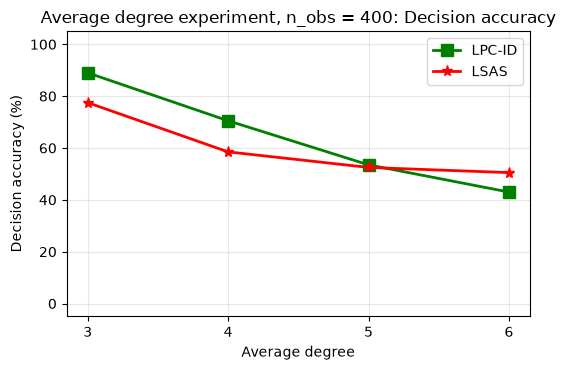

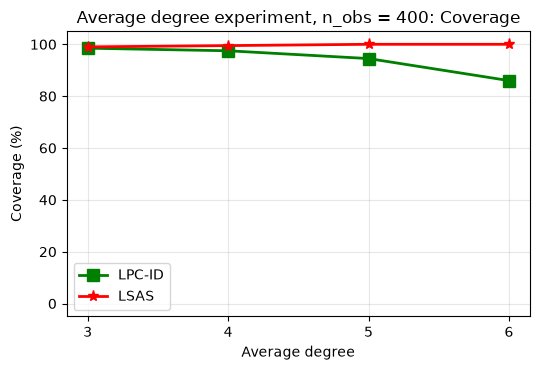

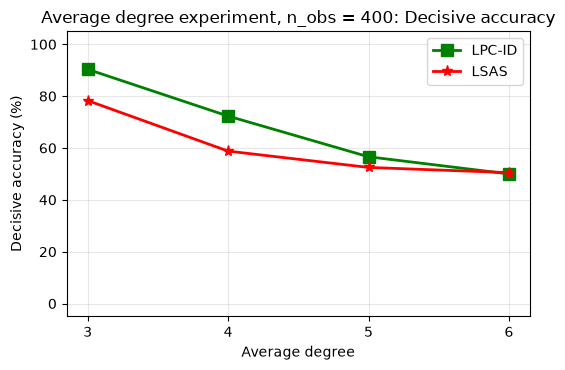

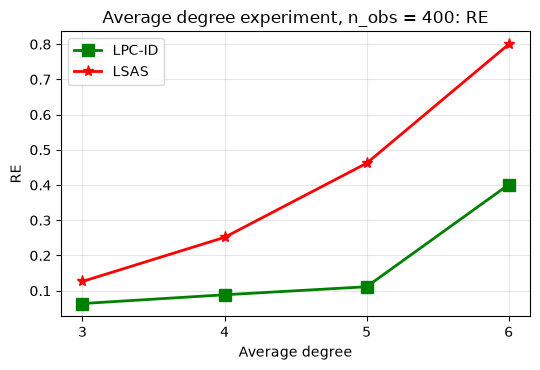

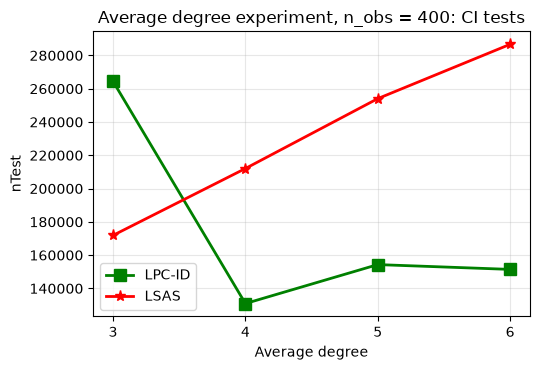

In [52]:
plot_experiment_metrics(
    decision_df=avg_degree_decision_metrics,
    effect_df=avg_degree_effect_effort,
    x_col="avg_degree",
    x_label="Average degree",
    title_prefix=f"Average degree experiment, n_obs = {BASE_N_OBS}",
)


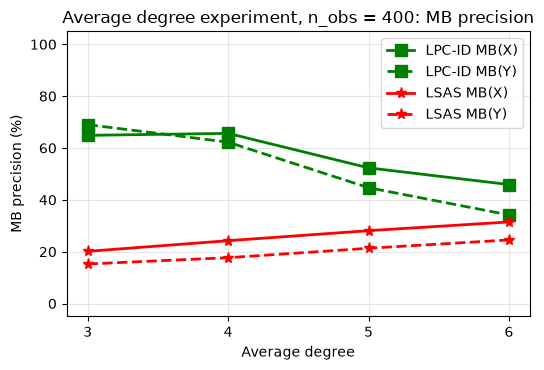

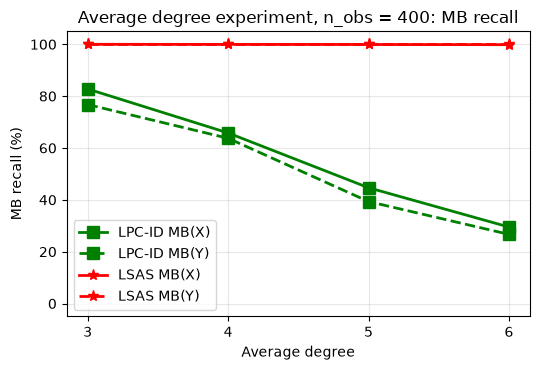

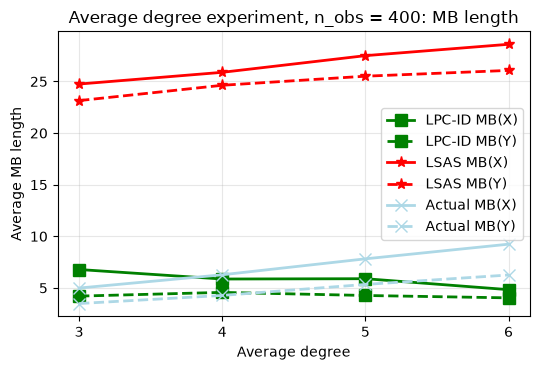

,avg_degree,method,target,n_reps,mean_mb_size,std_mb_size,mean_actual_mb_size,std_actual_mb_size,mean_mb_precision,std_mb_precision,mean_mb_recall,std_mb_recall
0,3,LPC-ID,X,200,6.785,3.561206,4.990,2.882960,0.648837,0.296648,0.827721,0.195689
1,3,LPC-ID,Y,200,4.210,2.137462,3.490,1.721837,0.690162,0.320800,0.767617,0.286624
2,3,LSAS,X,200,24.750,6.107702,4.990,2.882960,0.201336,0.105027,1.000000,0.000000
3,3,LSAS,Y,200,23.145,5.314621,3.490,1.721837,0.152619,0.072086,1.000000,0.000000
4,4,LPC-ID,X,200,5.865,2.733888,6.275,3.321829,0.656413,0.253267,0.658102,0.266948
5,4,LPC-ID,Y,200,4.570,2.411259,4.275,2.007367,0.622465,0.309003,0.637520,0.305186
6,4,LSAS,X,200,25.885,6.444333,6.275,3.321829,0.242415,0.117364,0.999581,0.005907
7,4,LSAS,Y,200,24.630,5.751390,4.275,2.007367,0.176834,0.081178,1.000000,0.000000
8,5,LPC-ID,X,200,5.895,2.398487,7.820,3.754742,0.523433,0.268633,0.446756,0.290177
9,5,LPC-ID,Y,200,4.270,1.732660,5.340,2.172093,0.446825,0.312559,0.393466,0.308680


In [53]:
avg_degree_mb_comparison, avg_degree_mb_comparison_detail = compare_markov_blankets(
    avg_degree_results,
    group_cols=["avg_degree"],
)

plot_markov_blanket_metrics(
    avg_degree_mb_comparison,
    x_col="avg_degree",
    x_label="Average degree",
    title_prefix=f"Average degree experiment, n_obs = {BASE_N_OBS}",
)

avg_degree_mb_comparison


## Nonlinearity Experiment


In [54]:
BASE_N_OBS = 100
BASE_P = TARGET_AVG_DEGREE / (BASE_N_OBS + 1)

In [55]:
beta_results_list = []

for beta_value in beta_values:
    results_one_beta = run_structure_experiment(
        structure_name=f"Nonlinearity experiment, beta={beta_value}",
        sample_sizes=[BASE_SAMPLE_SIZE],
        n_reps=BASE_N_REPS,
        n_obs=BASE_N_OBS,
        p=BASE_P,
        beta=beta_value,
        ci_method=BASE_CI_METHOD,
        max_z_size=MAX_Z_SIZE
        )
    results_one_beta["beta_value"] = beta_value
    beta_results_list.append(results_one_beta)

beta_results = pd.concat(beta_results_list, ignore_index=True)
beta_results



Running Nonlinearity experiment, beta=0 with sample size 5000 for 200 reps...


Processing Nonlinearity experiment, beta=0: 100%|██████████| 200/200 [03:04<00:00,  1.08it/s]


Running Nonlinearity experiment, beta=0.5 with sample size 5000 for 200 reps...


Processing Nonlinearity experiment, beta=0.5:  72%|███████▏  | 144/200 [43:59<17:06, 18.33s/it] 


KeyboardInterrupt: 

In [ ]:
beta_decision_metrics = (
    beta_results
    .groupby(["method", "beta_value"], as_index=False)
    .agg(
        decision_acc=("decision_correct", "mean"),
        coverage=("is_decisive", "mean"),
        n_reps=("decision", "size"),
    )
)

beta_decisive_metrics = (
    beta_results[beta_results["is_decisive"]]
    .groupby(["method", "beta_value"], as_index=False)
    .agg(
        decisive_acc=("decision_correct", "mean"),
        n_decisive=("decision", "size"),
    )
)

beta_decision_metrics = beta_decision_metrics.merge(
    beta_decisive_metrics,
    on=["method", "beta_value"],
    how="left",
)

beta_decision_metrics["n_decisive"] = beta_decision_metrics["n_decisive"].fillna(0).astype(int)

beta_decision_metrics


,method,beta_value,decision_acc,coverage,n_reps,decisive_acc,n_decisive
0,LSAS,0.0,0.79,1.00,100,0.79000,100
1,LSAS,0.5,0.75,1.00,100,0.75000,100
2,LSAS,1.0,0.98,1.00,100,0.98000,100
3,PC-EA,0.0,0.81,0.96,100,0.84375,96
4,PC-EA,0.5,0.83,1.00,100,0.83000,100
5,PC-EA,1.0,0.98,1.00,100,0.98000,100


In [ ]:
beta_effect_effort = (
    beta_results
    .groupby(["method", "beta_value"], as_index=False)
    .agg(
        mean_RE=("RE", "mean"),
        std_RE=("RE", "std"),
        mean_nTest=("nTest", "mean"),
        std_nTest=("nTest", "std"),
    )
)

beta_effect_effort


,method,beta_value,mean_RE,std_RE,mean_nTest,std_nTest
0,LSAS,0.0,0.177935,0.393547,2968.97,3321.379382
1,LSAS,0.5,5.317379,19.797644,3167.85,3439.100947
2,LSAS,1.0,0.771634,1.812951,2933.71,2289.253653
3,PC-EA,0.0,0.099910,0.264283,7970.60,5024.048914
4,PC-EA,0.5,3.629265,19.295913,8725.66,6652.960222
5,PC-EA,1.0,0.724053,1.399554,8412.11,5190.580701


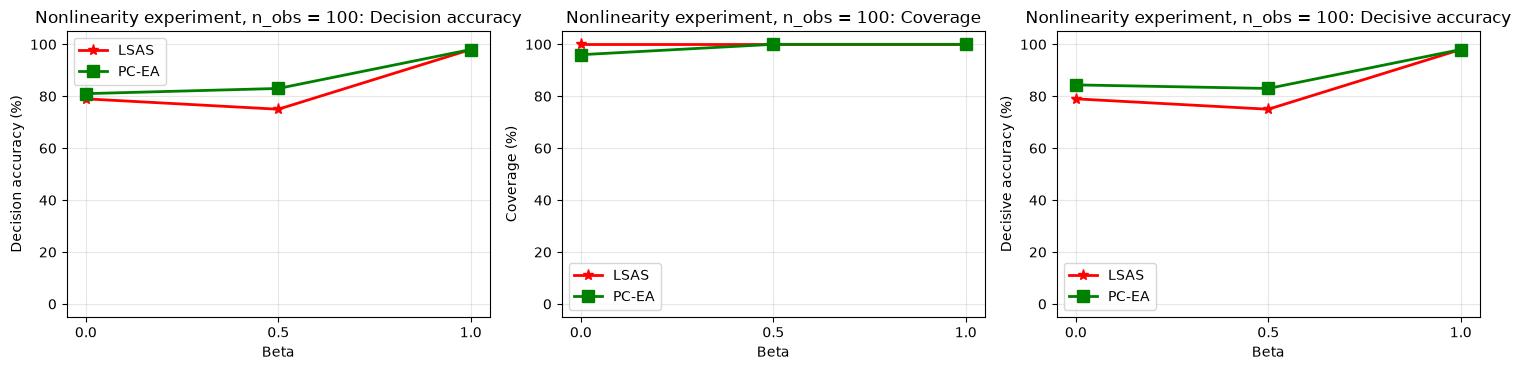

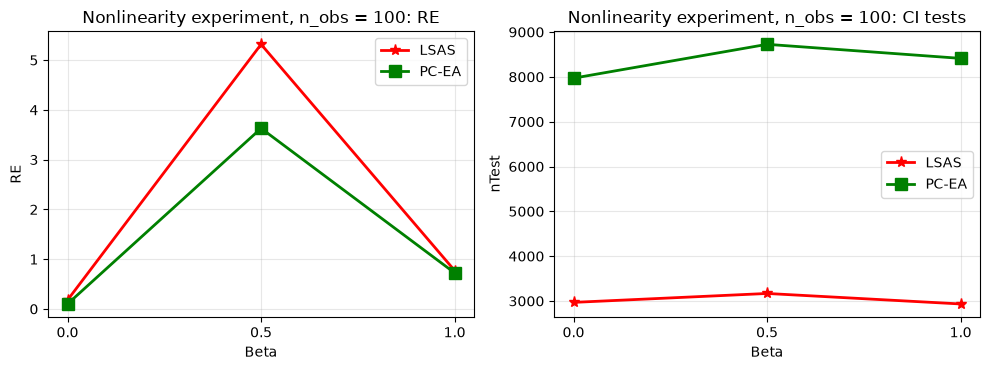

In [ ]:
plot_experiment_metrics(
    decision_df=beta_decision_metrics,
    effect_df=beta_effect_effort,
    x_col="beta_value",
    x_label="Beta",
    title_prefix=f"Nonlinearity experiment, n_obs = {BASE_N_OBS}",
)


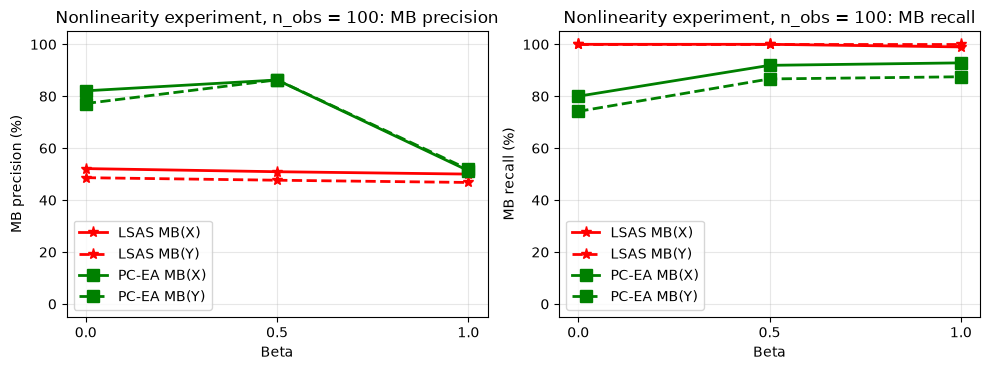

,beta_value,method,target,n_reps,mean_mb_precision,std_mb_precision,mean_mb_recall,std_mb_recall
0,0.0,LSAS,X,100,0.521364,0.185639,1.000000,0.000000
1,0.0,LSAS,Y,100,0.486325,0.166771,1.000000,0.000000
2,0.0,PC-EA,X,100,0.820877,0.216637,0.800000,0.209161
3,0.0,PC-EA,Y,100,0.772024,0.255519,0.741667,0.241436
4,0.5,LSAS,X,100,0.509310,0.169413,1.000000,0.000000
5,0.5,LSAS,Y,100,0.476582,0.161693,1.000000,0.000000
6,0.5,PC-EA,X,100,0.862631,0.139636,0.919048,0.084671
7,0.5,PC-EA,Y,100,0.863119,0.159469,0.866667,0.136083
8,1.0,LSAS,X,100,0.500173,0.174895,0.990000,0.036633
9,1.0,LSAS,Y,100,0.467952,0.151872,1.000000,0.000000


In [ ]:
beta_mb_comparison, beta_mb_comparison_detail = compare_markov_blankets(
    beta_results,
    group_cols=["beta_value"],
)

plot_markov_blanket_metrics(
    beta_mb_comparison,
    x_col="beta_value",
    x_label="Beta",
    title_prefix=f"Nonlinearity experiment, n_obs = {BASE_N_OBS}",
)

beta_mb_comparison
